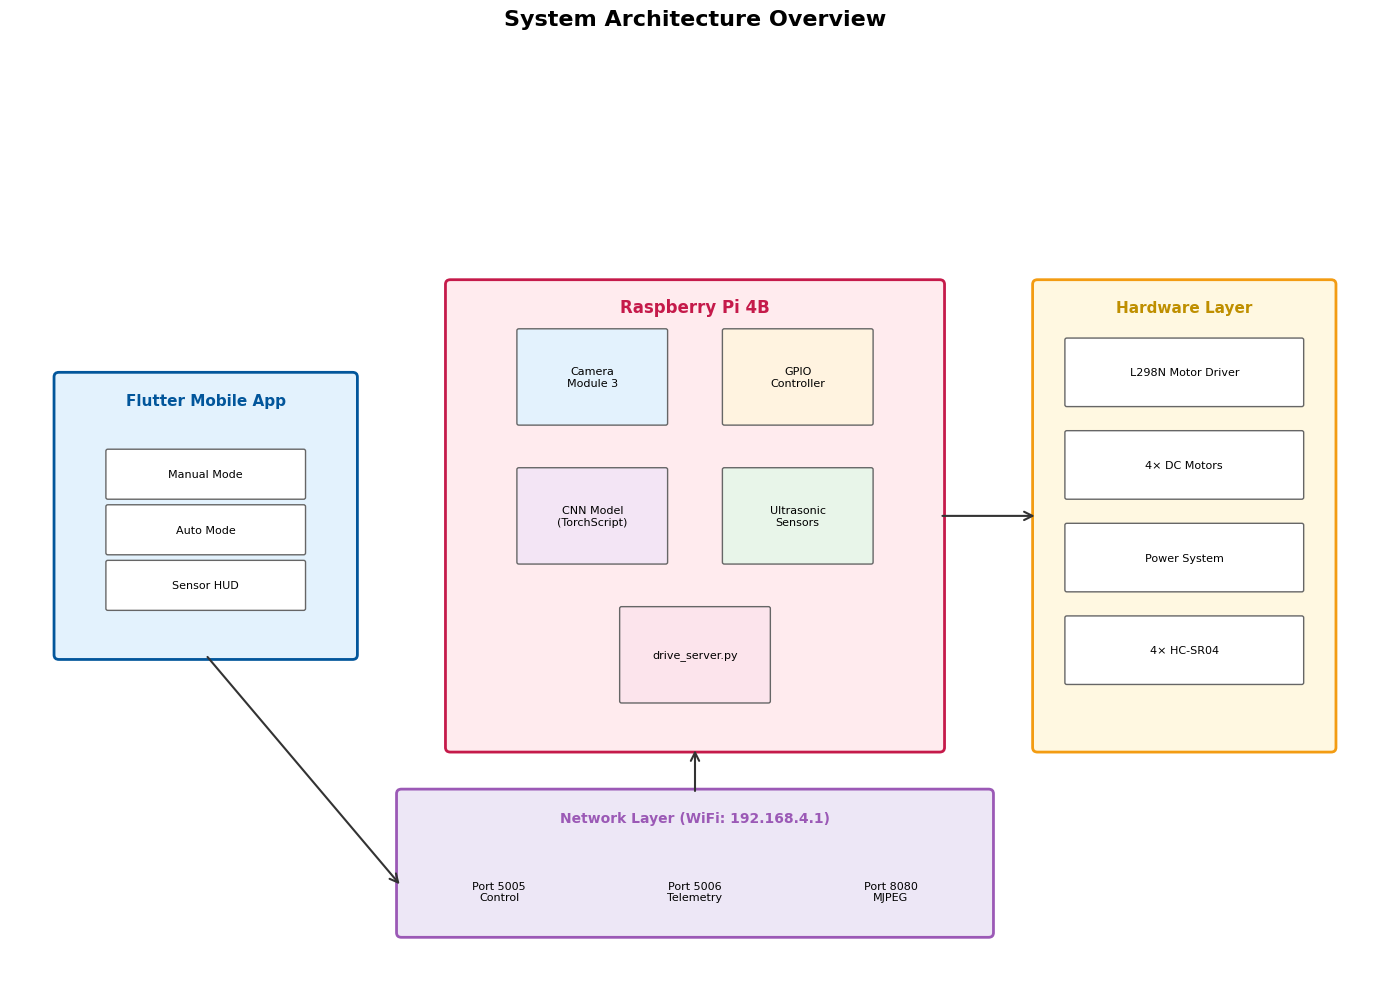

In [1]:
# 1

#!/usr/bin/env python3
"""System Architecture Overview Diagram"""

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

COLORS = {
    'raspberry': '#C51A4A', 'flutter': '#02569B', 
    'warning': '#F39C12', 'neural': '#9B59B6',
}

fig, ax = plt.subplots(figsize=(14, 10))
ax.set_xlim(0, 14)
ax.set_ylim(0, 10)
ax.axis('off')
ax.set_title('System Architecture Overview', fontsize=16, fontweight='bold', pad=20)

# === RASPBERRY PI SECTION (Center) ===
pi_box = FancyBboxPatch((4.5, 2.5), 5, 5, boxstyle="round,pad=0.05", 
                         facecolor='#ffebee', edgecolor=COLORS['raspberry'], linewidth=2)
ax.add_patch(pi_box)
ax.text(7, 7.2, 'Raspberry Pi 4B', fontsize=12, fontweight='bold', ha='center', color=COLORS['raspberry'])

components = [
    (5.2, 6.0, 'Camera\nModule 3', '#e3f2fd'),
    (7.3, 6.0, 'GPIO\nController', '#fff3e0'),
    (5.2, 4.5, 'CNN Model\n(TorchScript)', '#f3e5f5'),
    (7.3, 4.5, 'Ultrasonic\nSensors', '#e8f5e9'),
    (6.25, 3.0, 'drive_server.py', '#fce4ec'),
]

for x, y, text, color in components:
    box = FancyBboxPatch((x, y), 1.5, 1.0, boxstyle="round,pad=0.02",
                         facecolor=color, edgecolor='#666', linewidth=1)
    ax.add_patch(box)
    ax.text(x + 0.75, y + 0.5, text, fontsize=8, ha='center', va='center')

# === MOBILE APP (Left) ===
app_box = FancyBboxPatch((0.5, 3.5), 3, 3, boxstyle="round,pad=0.05",
                          facecolor='#e3f2fd', edgecolor=COLORS['flutter'], linewidth=2)
ax.add_patch(app_box)
ax.text(2, 6.2, 'Flutter Mobile App', fontsize=11, fontweight='bold', ha='center', color=COLORS['flutter'])

for text, y in [('Manual Mode', 5.2), ('Auto Mode', 4.6), ('Sensor HUD', 4.0)]:
    box = FancyBboxPatch((1, y), 2, 0.5, boxstyle="round,pad=0.02",
                         facecolor='white', edgecolor='#666', linewidth=1)
    ax.add_patch(box)
    ax.text(2, y + 0.25, text, fontsize=8, ha='center', va='center')

# === HARDWARE (Right) ===
hw_box = FancyBboxPatch((10.5, 2.5), 3, 5, boxstyle="round,pad=0.05",
                         facecolor='#fff8e1', edgecolor=COLORS['warning'], linewidth=2)
ax.add_patch(hw_box)
ax.text(12, 7.2, 'Hardware Layer', fontsize=11, fontweight='bold', ha='center', color='#bf8f00')

for text, y in [('L298N Motor Driver', 6.2), ('4× DC Motors', 5.2), ('Power System', 4.2), ('4× HC-SR04', 3.2)]:
    box = FancyBboxPatch((10.8, y), 2.4, 0.7, boxstyle="round,pad=0.02",
                         facecolor='white', edgecolor='#666', linewidth=1)
    ax.add_patch(box)
    ax.text(12, y + 0.35, text, fontsize=8, ha='center', va='center')

# === NETWORK (Bottom) ===
net_box = FancyBboxPatch((4, 0.5), 6, 1.5, boxstyle="round,pad=0.05",
                          facecolor='#ede7f6', edgecolor=COLORS['neural'], linewidth=2)
ax.add_patch(net_box)
ax.text(7, 1.7, 'Network Layer (WiFi: 192.168.4.1)', fontsize=10, fontweight='bold', ha='center', color=COLORS['neural'])
ax.text(5, 0.85, 'Port 5005\nControl', fontsize=8, ha='center')
ax.text(7, 0.85, 'Port 5006\nTelemetry', fontsize=8, ha='center')
ax.text(9, 0.85, 'Port 8080\nMJPEG', fontsize=8, ha='center')

# === ARROWS ===
arrow_props = dict(arrowstyle='->', color='#333', lw=1.5, mutation_scale=15)
ax.annotate('', xy=(4, 1), xytext=(2, 3.5), arrowprops=arrow_props)
ax.annotate('', xy=(7, 2.5), xytext=(7, 2), arrowprops=arrow_props)
ax.annotate('', xy=(10.5, 5), xytext=(9.5, 5), arrowprops=arrow_props)

plt.tight_layout()
plt.show()

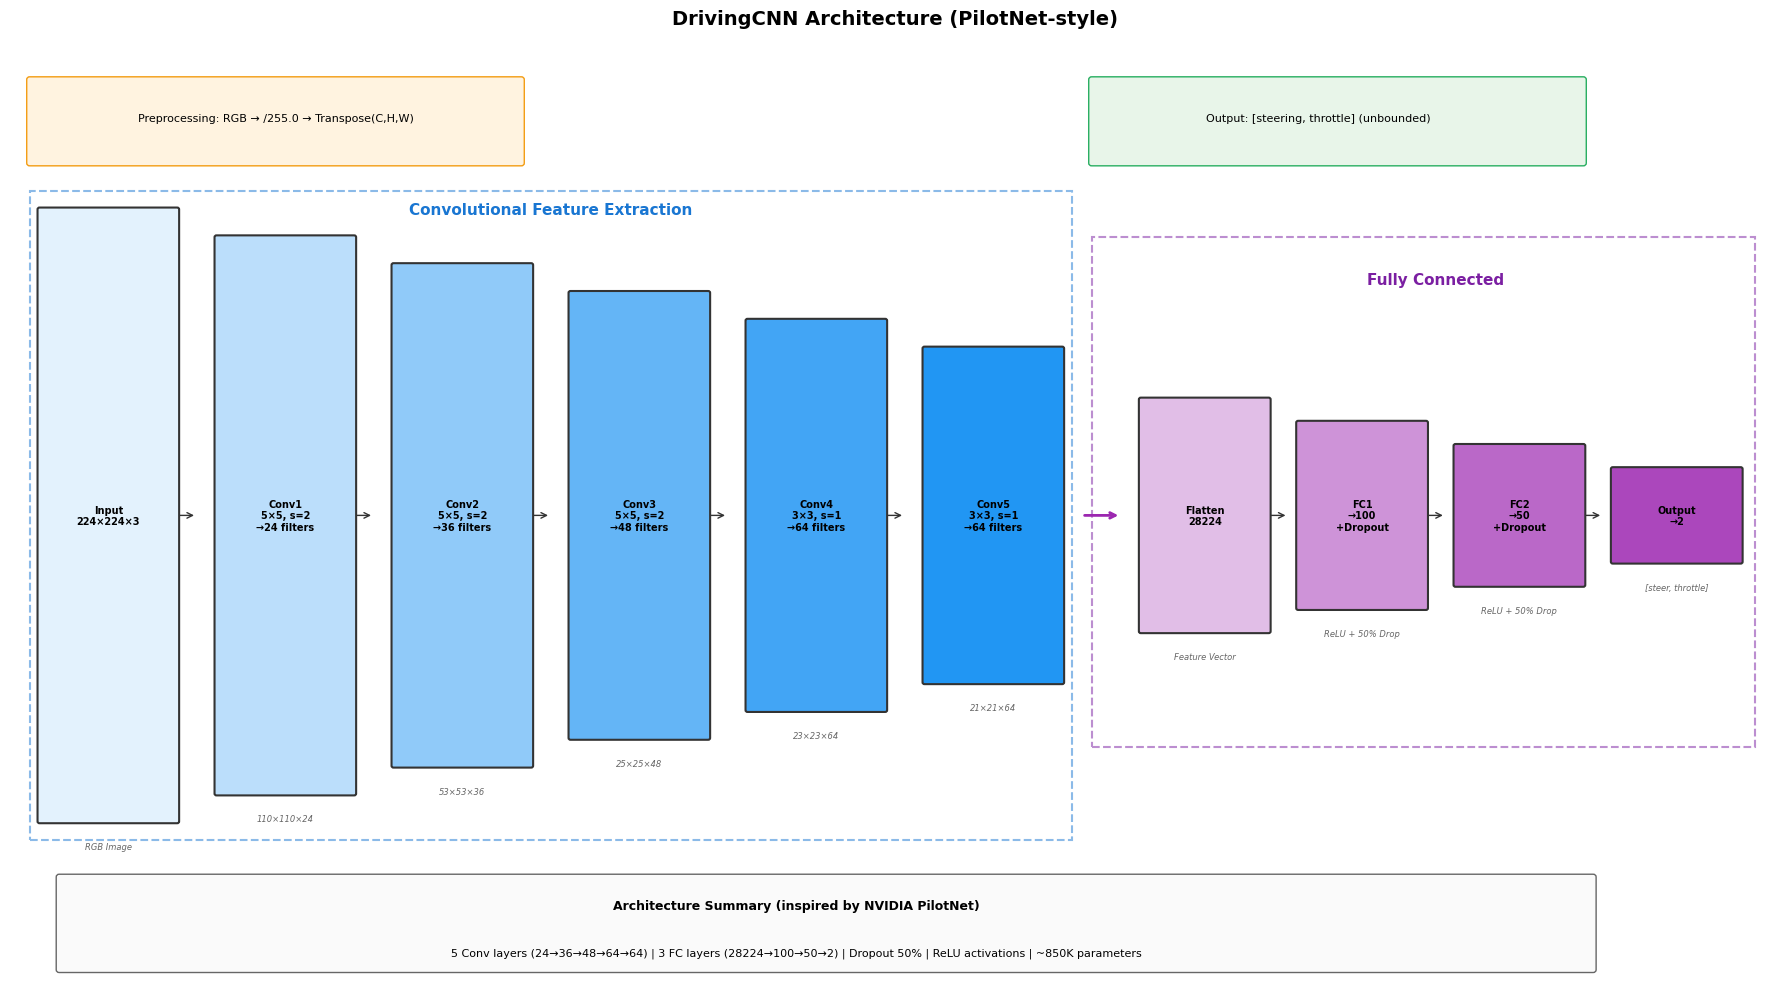

In [4]:
# 2

#!/usr/bin/env python3
"""
CORRECTED CNN Model Architecture Diagram
Based on actual model.py - PilotNet-style architecture, NOT ResNet18
"""

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Rectangle

fig, ax = plt.subplots(figsize=(18, 10))
ax.set_xlim(0, 18)
ax.set_ylim(0, 10)
ax.axis('off')
ax.set_title('DrivingCNN Architecture (PilotNet-style)', fontsize=14, fontweight='bold', pad=20)

# Actual layer definitions from model.py
conv_layers = [
    ('Input\n224×224×3', 2.2, '#e3f2fd', 'RGB Image'),
    ('Conv1\n5×5, s=2\n→24 filters', 2.0, '#bbdefb', '110×110×24'),
    ('Conv2\n5×5, s=2\n→36 filters', 1.8, '#90caf9', '53×53×36'),
    ('Conv3\n5×5, s=2\n→48 filters', 1.6, '#64b5f6', '25×25×48'),
    ('Conv4\n3×3, s=1\n→64 filters', 1.4, '#42a5f5', '23×23×64'),
    ('Conv5\n3×3, s=1\n→64 filters', 1.2, '#2196f3', '21×21×64'),
]

fc_layers = [
    ('Flatten\n28224', 1.0, '#e1bee7', 'Feature Vector'),
    ('FC1\n→100\n+Dropout', 0.8, '#ce93d8', 'ReLU + 50% Drop'),
    ('FC2\n→50\n+Dropout', 0.6, '#ba68c8', 'ReLU + 50% Drop'),
    ('Output\n→2', 0.4, '#ab47bc', '[steer, throttle]'),
]

y_center = 5
x_start = 0.3

# Draw convolutional layers
for i, (name, height_scale, color, desc) in enumerate(conv_layers):
    x = x_start + i * 1.8
    h = 3 * height_scale
    y = y_center - h/2
    
    rect = FancyBboxPatch((x, y), 1.4, h, boxstyle="round,pad=0.02",
                           facecolor=color, edgecolor='#333', linewidth=1.5)
    ax.add_patch(rect)
    ax.text(x + 0.7, y_center, name, fontsize=7, ha='center', va='center', fontweight='bold')
    
    if i < len(conv_layers) - 1:
        ax.annotate('', xy=(x + 1.6, y_center), xytext=(x + 1.4, y_center),
                   arrowprops=dict(arrowstyle='->', color='#333', lw=1))
    
    ax.text(x + 0.7, y - 0.3, desc, fontsize=6, ha='center', color='#666', style='italic')

# Arrow from conv to FC
ax.annotate('', xy=(x_start + len(conv_layers) * 1.8 + 0.2, y_center), 
           xytext=(x_start + len(conv_layers) * 1.8 - 0.2, y_center),
           arrowprops=dict(arrowstyle='->', color='#9C27B0', lw=2))

# Draw FC layers
fc_x_start = x_start + len(conv_layers) * 1.8 + 0.4
for i, (name, height_scale, color, desc) in enumerate(fc_layers):
    x = fc_x_start + i * 1.6
    h = 2.5 * height_scale
    y = y_center - h/2
    
    rect = FancyBboxPatch((x, y), 1.3, h, boxstyle="round,pad=0.02",
                           facecolor=color, edgecolor='#333', linewidth=1.5)
    ax.add_patch(rect)
    ax.text(x + 0.65, y_center, name, fontsize=7, ha='center', va='center', fontweight='bold')
    
    if i < len(fc_layers) - 1:
        ax.annotate('', xy=(x + 1.5, y_center), xytext=(x + 1.3, y_center),
                   arrowprops=dict(arrowstyle='->', color='#333', lw=1))
    
    ax.text(x + 0.65, y - 0.3, desc, fontsize=6, ha='center', color='#666', style='italic')

# Labels for sections
ax.text(5.5, 8.25, 'Convolutional Feature Extraction', fontsize=11, fontweight='bold', 
        ha='center', color='#1976D2') 
ax.add_patch(Rectangle((0.2, 1.5), 10.6, 7, fill=False, edgecolor='#1976D2', 
                        linestyle='--', linewidth=1.5, alpha=0.5))

ax.text(14.5, 7.5, 'Fully Connected', fontsize=11, fontweight='bold', 
        ha='center', color='#7B1FA2')
ax.add_patch(Rectangle((11, 2.5), 6.75, 5.5, fill=False, edgecolor='#7B1FA2', 
                        linestyle='--', linewidth=1.5, alpha=0.5))

# Preprocessing note
preprocess_box = FancyBboxPatch((0.2, 8.8), 5, 0.9, boxstyle="round,pad=0.03",
                                 facecolor='#fff3e0', edgecolor='#F39C12', linewidth=1)
ax.add_patch(preprocess_box)
ax.text(2.7, 9.25, 'Preprocessing: RGB → /255.0 → Transpose(C,H,W)', fontsize=8, ha='center')

# Output note
output_box = FancyBboxPatch((11, 8.8), 5, 0.9, boxstyle="round,pad=0.03",
                             facecolor='#e8f5e9', edgecolor='#27AE60', linewidth=1)
ax.add_patch(output_box)
ax.text(13.3, 9.25, 'Output: [steering, throttle] (unbounded)', fontsize=8, ha='center')

# Architecture summary box
summary_box = FancyBboxPatch((0.5, 0.1), 15.6, 1, boxstyle="round,pad=0.03",
                              facecolor='#fafafa', edgecolor='#666', linewidth=1)
ax.add_patch(summary_box)
ax.text(8, 0.75, 'Architecture Summary (inspired by NVIDIA PilotNet)', fontsize=9, 
        fontweight='bold', ha='center')
ax.text(8, 0.25, '5 Conv layers (24→36→48→64→64) | 3 FC layers (28224→100→50→2) | '
        'Dropout 50% | ReLU activations | ~850K parameters', fontsize=8, ha='center')

plt.tight_layout()
plt.show()

In [ ]:
#!/usr/bin/env python3
"""Behavioral Cloning Pipeline Diagram - High-Res Version for IEEE"""

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

# Use sans-serif fonts (closer to IEEE style - many journals accept Arial/Helvetica)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans', 'Liberation Sans']

# Bigger figure for high resolution
fig, ax = plt.subplots(figsize=(18, 11.5), dpi=600)  # 300 dpi is good balance, you can go to 600

ax.set_xlim(0, 18)
ax.set_ylim(0, 11.5)
ax.axis('off')

# === DATA COLLECTION PHASE ===
ax.text(4.5, 10.2, 'Phase 1: Data Collection', fontsize=16, fontweight='bold', ha='center', color='#2C3E50')

phase1_box = FancyBboxPatch((0.3, 7.8), 9.75, 2.2, boxstyle="round,pad=0.06",
                            facecolor='#e3f2fd', edgecolor='#2196F3', linewidth=2.2)
ax.add_patch(phase1_box)

collection_steps = [
    (0.6, 8.0, 'Human Expert\nDriver', '#e3f2fd'),
    (3.0, 8.0, 'Manual Mode\n(Dual Joysticks)', '#bbdefb'),
    (5.4, 8.0, 'Camera\nCapture\n(640×480)', '#90caf9'),
    (7.8, 8.0, 'Sync Labels\n(steering,\nthrottle)', '#64b5f6'),
]

for x, y, text, color in collection_steps:
    box = FancyBboxPatch((x, y), 2.0, 1.8, boxstyle="round,pad=0.04",
                         facecolor=color, edgecolor='#333', linewidth=1.8)
    ax.add_patch(box)
    ax.text(x + 1.0, y + 0.9, text, fontsize=10, ha='center', va='center', linespacing=1.1)

for i in range(3):
    ax.annotate('', xy=(2.5 + i*2.4 + 0.5, 9.0), xytext=(2.5 + i*2.4 + 0.1, 9.0),
                arrowprops=dict(arrowstyle='->', color='#333', lw=2))

# === PREPROCESSING PHASE ===
ax.text(14, 10.2, 'Phase 2: Preprocessing', fontsize=16, fontweight='bold', ha='center', color='#F39C12')

phase2_box = FancyBboxPatch((10.4, 7.8), 7.2, 2.2, boxstyle="round,pad=0.06",
                            facecolor='#fff3e0', edgecolor='#FF9800', linewidth=2.2)
ax.add_patch(phase2_box)

preprocess_steps = [
    (10.6, 8.0, 'Dataset\nCleaning\n(throttle≥0.2)', '#fff3e0'),
    (13.0, 8.0, 'Resize to\n224×224', '#ffe0b2'),
    (15.4, 8.0, 'Normalize\n/255.0', '#ffcc80'),
]

for x, y, text, color in preprocess_steps:
    box = FancyBboxPatch((x, y), 2.0, 1.8, boxstyle="round,pad=0.04",
                         facecolor=color, edgecolor='#333', linewidth=1.8)
    ax.add_patch(box)
    ax.text(x + 1.0, y + 0.9, text, fontsize=10, ha='center', va='center', linespacing=1.1)

ax.annotate('', xy=(10.4, 9.0), xytext=(10.1, 9.0),
            arrowprops=dict(arrowstyle='->', color='#2C3E50', lw=2.5))

for i in range(2):
    ax.annotate('', xy=(12.5 + i*2.4 + 0.5, 9.0), xytext=(12.5 + i*2.4 + 0.1, 9.0),
                arrowprops=dict(arrowstyle='->', color='#333', lw=2))

# === TRAINING PHASE ===
ax.text(9, 6.2, 'Phase 3: Model Training (NVIDIA RTX Workstation)', fontsize=16, 
        fontweight='bold', ha='center', color='#9B59B6')

training_box = FancyBboxPatch((0.8, 3.2), 15.4, 2.4, boxstyle="round,pad=0.06",
                              facecolor='#f3e5f5', edgecolor='#9B59B6', linewidth=2.2)
ax.add_patch(training_box)

train_steps = [
    (1.4, 3.8, 'Train/Val\nSplit\n(80/20)', '#e1bee7'),
    (4.4, 3.8, 'Data\nAugmentation\n(train only)', '#ce93d8'),
    (7.4, 3.8, 'DrivingCNN\n(PilotNet)', '#ba68c8'),
    (10.4, 3.8, 'MSE Loss +\nAdam\n(lr=1e-4)', '#ab47bc'),
    (13.4, 3.8, 'Early Stop\n+ LR\nScheduler', '#9c27b0'),
]

for x, y, text, color in train_steps:
    box = FancyBboxPatch((x, y), 2.2, 1.6, boxstyle="round,pad=0.03",
                         facecolor=color, edgecolor='#333', linewidth=1.4)
    ax.add_patch(box)
    ax.text(x + 1.1, y + 0.8, text, fontsize=9, ha='center', va='center', linespacing=1.1)

for i in range(4):
    ax.annotate('', xy=(3.9 + i*3 + 0.5, 4.6), xytext=(3.5 + i*3 + 0.1, 4.6),
                arrowprops=dict(arrowstyle='->', color='#333', lw=1.8))

ax.annotate('', xy=(15, 5.6), xytext=(15, 7.8),
            arrowprops=dict(arrowstyle='->', color='#9B59B6', lw=2.5))

# === DEPLOYMENT PHASE ===
ax.text(9, 2.4, 'Phase 4: Deployment', fontsize=16, fontweight='bold', ha='center', color='#27AE60')

deployment_box = FancyBboxPatch((1.2, 0.3), 15.6, 2.0, boxstyle="round,pad=0.05",
                                facecolor='#e8f5e9', edgecolor='#27AE60', linewidth=2.2)
ax.add_patch(deployment_box)

deploy_steps = [
    (2.0, 0.7, 'model_best.pth', '#e8f5e9'),
    (5.0, 0.7, 'Dynamic\nQuantization', '#c8e6c9'),
    (8.0, 0.7, 'TorchScript\nExport', '#a5d6a7'),
    (11.0, 0.7, 'Deploy to\nRaspberry Pi', '#81c784'),
    (14.0, 0.7, 'Real-time\nInference\n(~20 FPS)', '#66bb6a'),
]

for x, y, text, color in deploy_steps:
    box = FancyBboxPatch((x, y), 2.4, 1.4, boxstyle="round,pad=0.03",
                         facecolor=color, edgecolor='#333', linewidth=1.6)
    ax.add_patch(box)
    ax.text(x + 1.2, y + 0.7, text, fontsize=10, ha='center', va='center', linespacing=1.1)

for i in range(4):
    ax.annotate('', xy=(4.5 + i*3 + 0.5, 1.5), xytext=(4.3 + i*3 + 0.1, 1.5),
                arrowprops=dict(arrowstyle='->', color='#333', lw=1.8))

ax.annotate('', xy=(4, 3.2), xytext=(4, 2.3),
            arrowprops=dict(arrowstyle='<-', color='#27AE60', lw=2.5))

plt.tight_layout(pad=1.2)

# Save high-resolution version (use .png or .pdf — both accepted by IEEE)
#plt.savefig('behavioral_cloning_pipeline_highres.png', dpi=600, bbox_inches='tight')
#plt.savefig('behavioral_cloning_pipeline_highres.pdf', bbox_inches='tight')  # vector format - best choice!

# Optional: still show on screen if you want
plt.show()

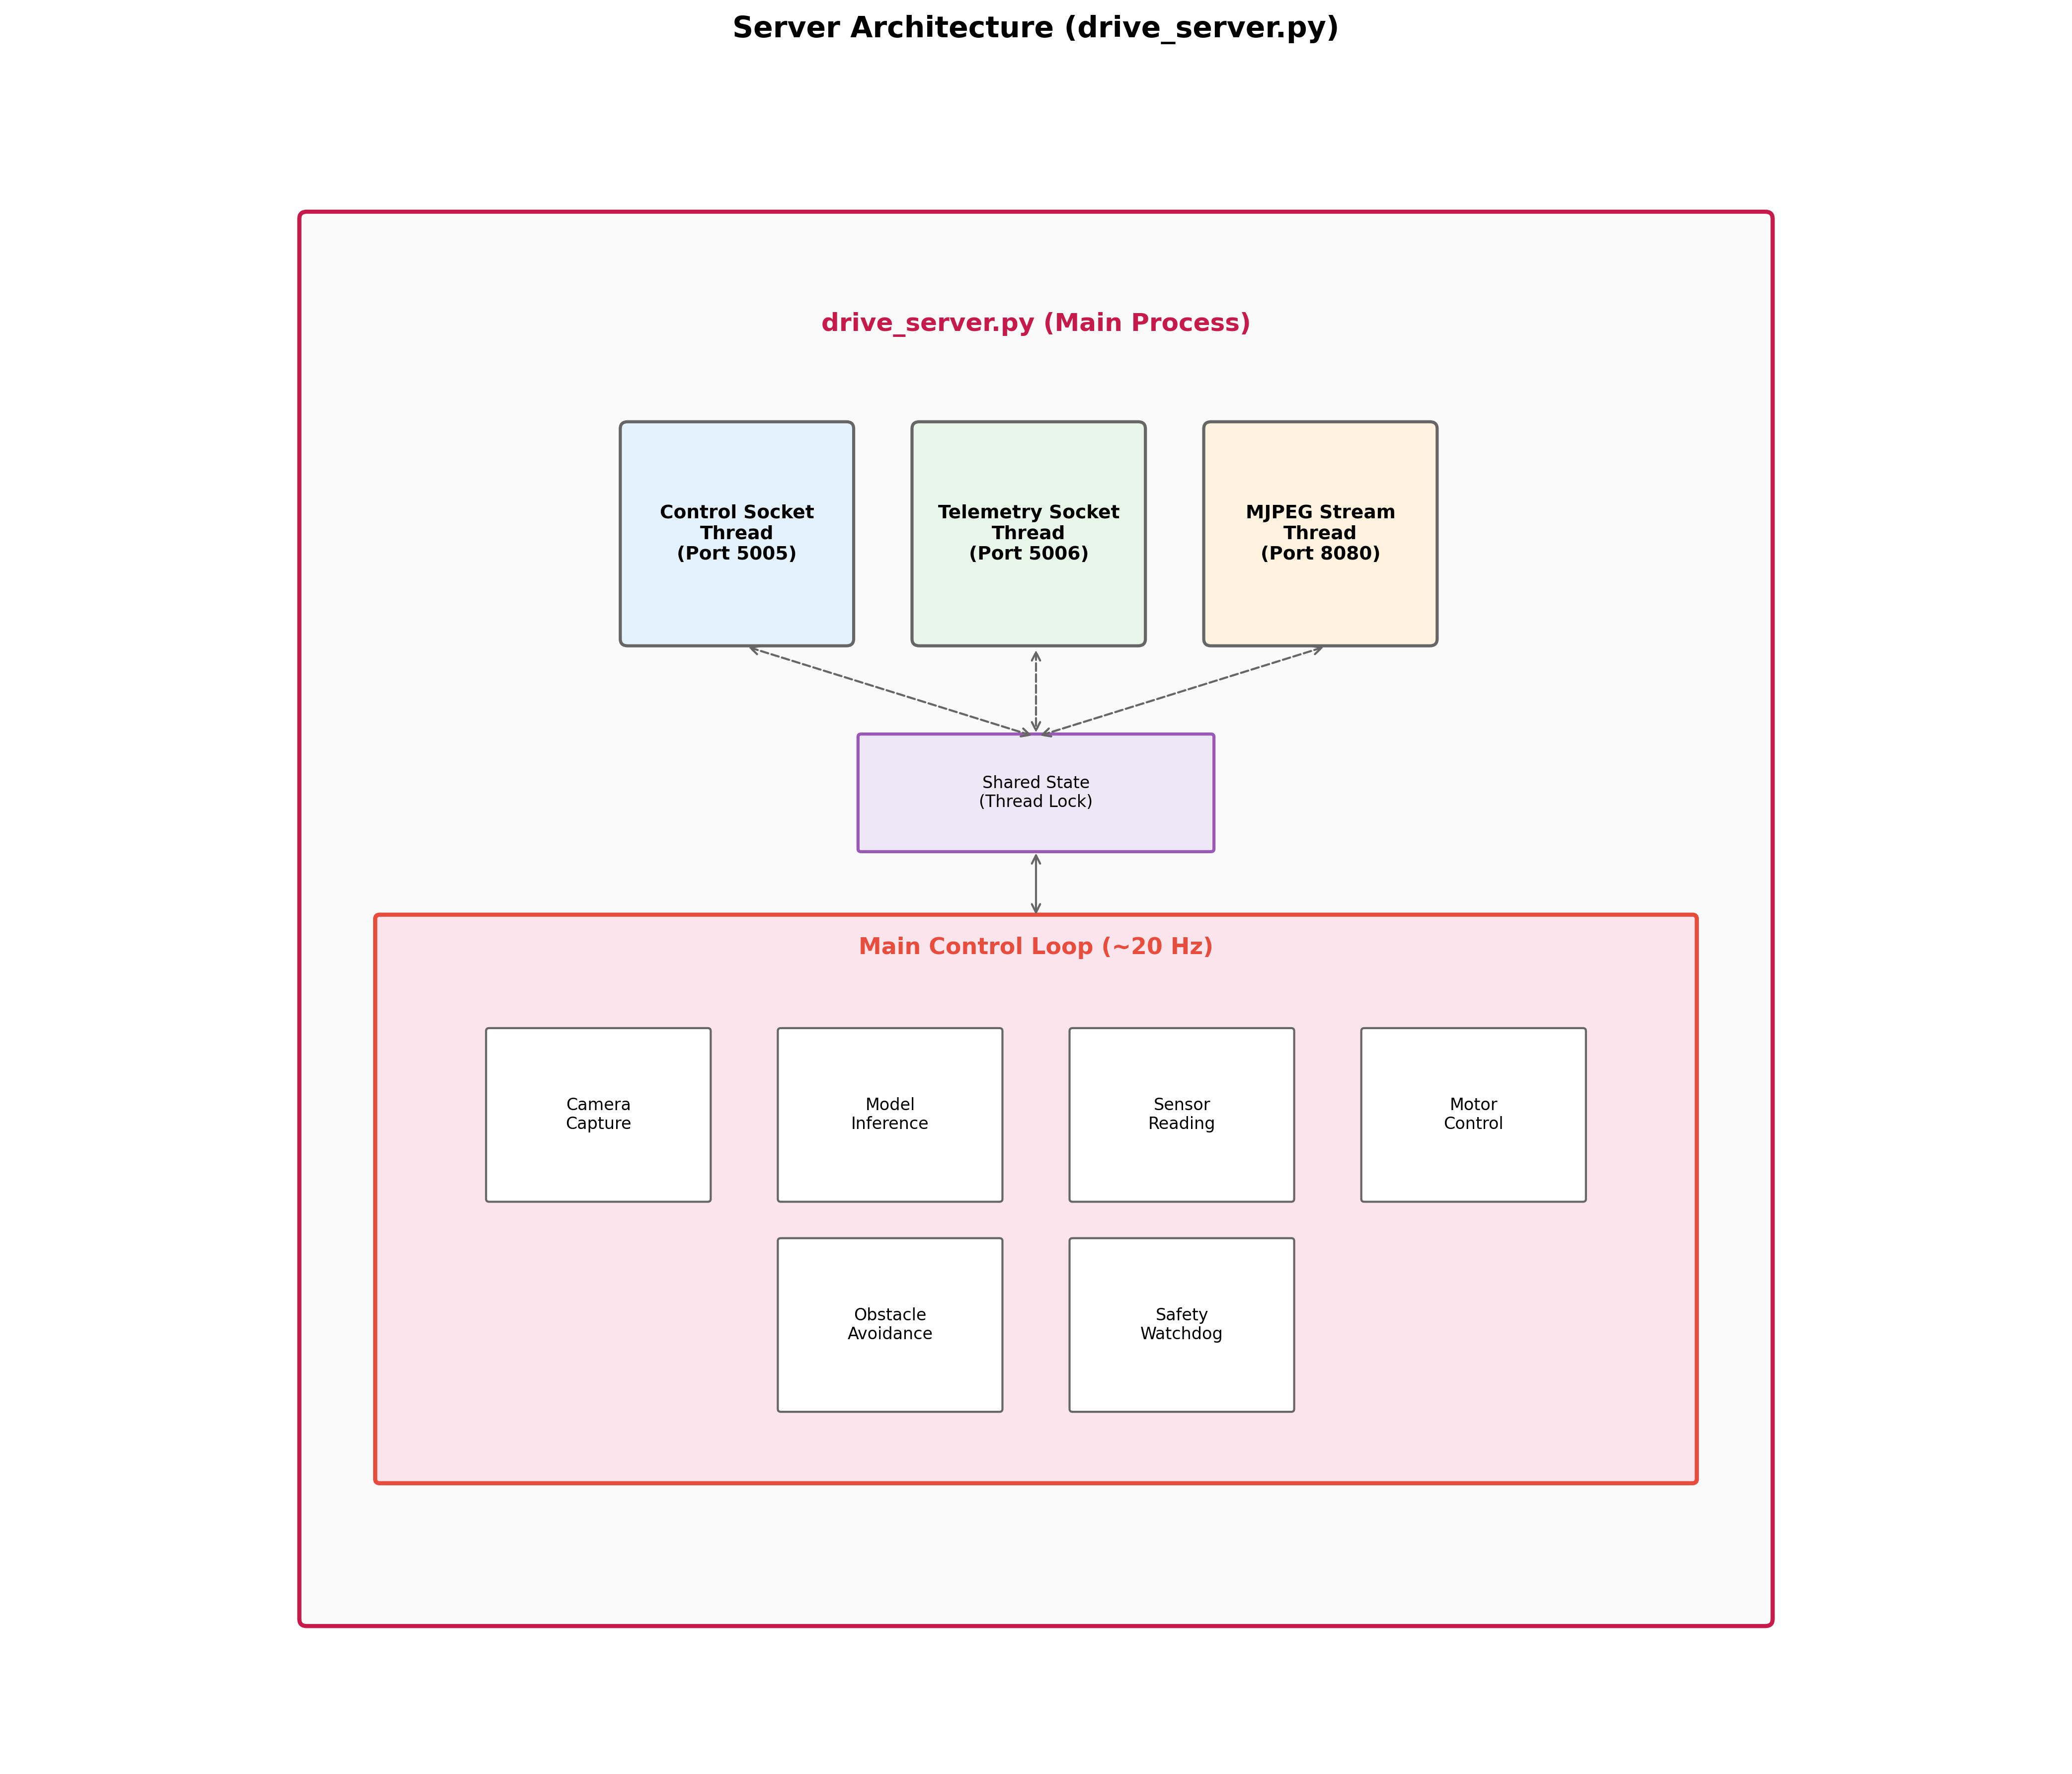

In [1]:
#!/usr/bin/env python3
"""Server Architecture (drive_server.py) Diagram - High Resolution Export"""

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

# Create figure with higher DPI for publication quality
fig, ax = plt.subplots(figsize=(14, 12), dpi=300)
ax.set_xlim(0, 14)
ax.set_ylim(0, 12)
ax.axis('off')
ax.set_title('Server Architecture (drive_server.py)', fontsize=14, fontweight='bold', pad=20)

# Main server process
main_box = FancyBboxPatch((2, 1), 10, 10, boxstyle="round,pad=0.05",
                           facecolor='#fafafa', edgecolor='#C51A4A', linewidth=2)
ax.add_patch(main_box)
ax.text(7, 10.2, 'drive_server.py (Main Process)', fontsize=12, fontweight='bold',
        ha='center', color='#C51A4A')

# Thread boxes
threads = [
    (4.2, 8.0, 1.5, 1.5, 'Control Socket\nThread\n(Port 5005)', '#e3f2fd'),
    (6.2, 8.0, 1.5, 1.5, 'Telemetry Socket\nThread\n(Port 5006)', '#e8f5e9'),
    (8.2, 8.0, 1.5, 1.5, 'MJPEG Stream\nThread\n(Port 8080)', '#fff3e0'),
]

for x, y, w, h, text, color in threads:
    box = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.05",
                         facecolor=color, edgecolor='#666', linewidth=1.5)
    ax.add_patch(box)
    ax.text(x + w/2, y + h/2, text, fontsize=9, ha='center', va='center', fontweight='bold')

# Main Control Loop
loop_box = FancyBboxPatch((2.5, 2), 9, 4, boxstyle="round,pad=0.03",
                           facecolor='#fce4ec', edgecolor='#E74C3C', linewidth=2)
ax.add_patch(loop_box)
ax.text(7, 5.75, 'Main Control Loop (~20 Hz)', fontsize=11, fontweight='bold',
        ha='center', color='#E74C3C')

# Loop components
loop_components = [
    (3.25, 4, 'Camera\nCapture'),
    (5.25, 4, 'Model\nInference'),
    (7.25, 4, 'Sensor\nReading'),
    (9.25, 4, 'Motor\nControl'),
    (5.25, 2.5, 'Obstacle\nAvoidance'),
    (7.25, 2.5, 'Safety\nWatchdog'),
]

for x, y, text in loop_components:
    box = FancyBboxPatch((x, y), 1.5, 1.2, boxstyle="round,pad=0.02",
                         facecolor='white', edgecolor='#666', linewidth=1)
    ax.add_patch(box)
    ax.text(x + 0.75, y + 0.6, text, fontsize=8, ha='center', va='center')

# Shared state
state_box = FancyBboxPatch((5.8, 6.5), 2.4, 0.8, boxstyle="round,pad=0.02",
                            facecolor='#ede7f6', edgecolor='#9B59B6', linewidth=1.5)
ax.add_patch(state_box)
ax.text(7, 6.9, 'Shared State\n(Thread Lock)', fontsize=8, ha='center', va='center')

# Arrows from threads to shared state
for x in [5, 7, 9]:
    ax.annotate('', xy=(7, 7.3), xytext=(x, 7.95),
               arrowprops=dict(arrowstyle='<->', color='#666', lw=1, ls='--'))

ax.annotate('', xy=(7, 6.5), xytext=(7, 6),
           arrowprops=dict(arrowstyle='<->', color='#666', lw=1))

plt.tight_layout()
plt.show()

# Save as high-resolution PNG for publication
# 300 DPI is standard for print, but we use 600 DPI for maximum clarity
#plt.savefig('diagrams/server_architecture.png', 
 #           dpi=600,  # High DPI for publication quality
 #           bbox_inches='tight',  # Remove extra whitespace
 #           pad_inches=0.1,  # Small padding
 #           facecolor='white',  # White background
 #           edgecolor='none',
 #           format='png')

#print("Diagram saved as 'server_architecture.png' at 600 DPI")
#print(f"Approximate dimensions: {14*600} x {12*600} pixels (8400 x 7200)")

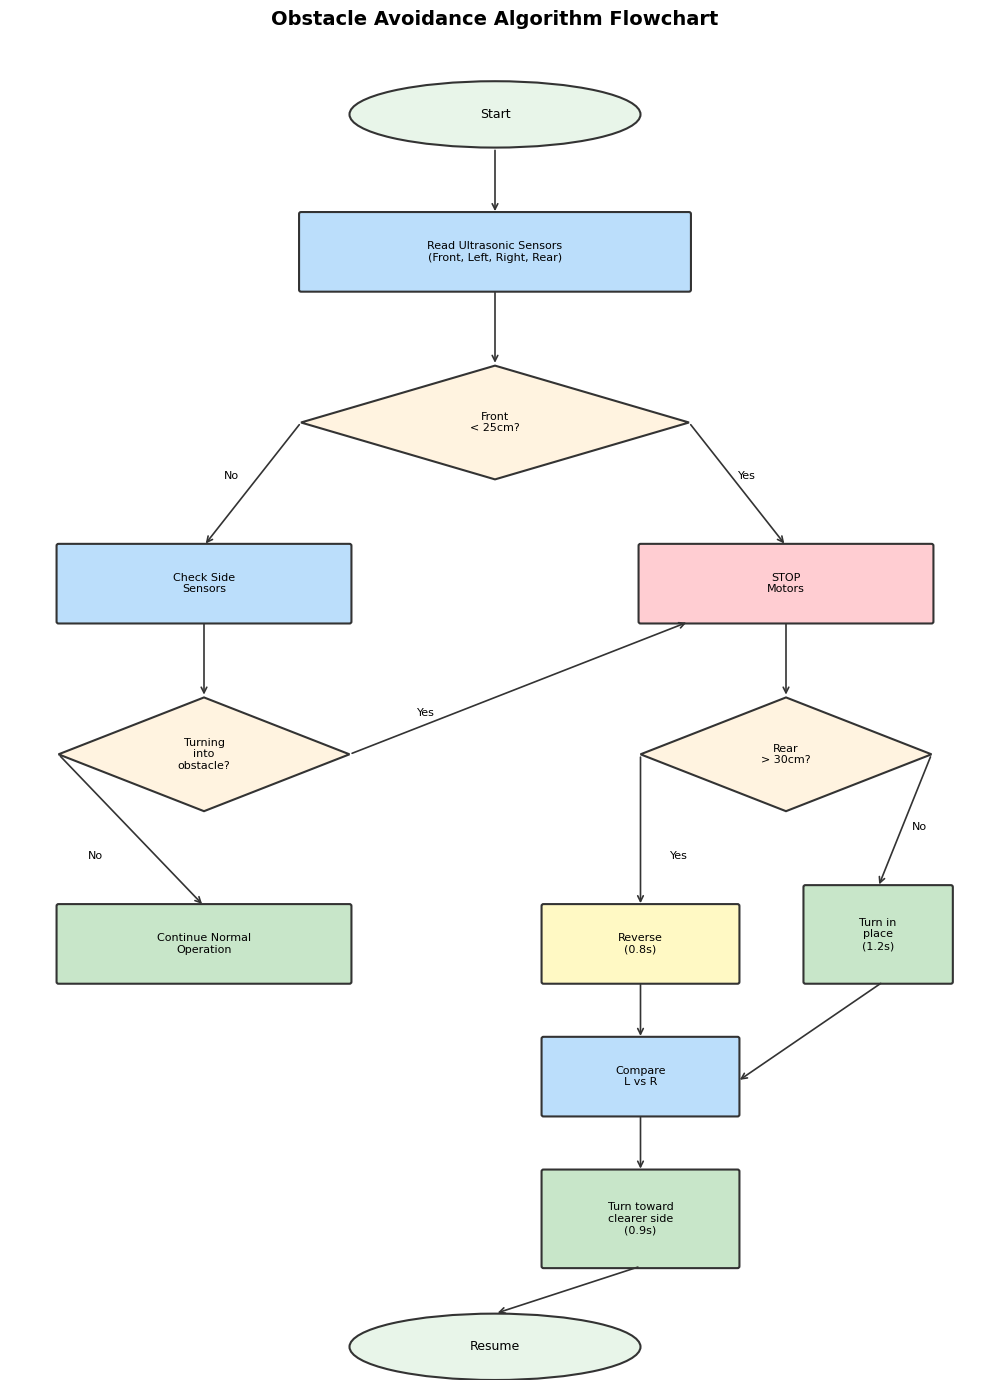

In [800]:
# 5

#!/usr/bin/env python3
"""Obstacle Avoidance Algorithm Flowchart"""

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Polygon, Ellipse

fig, ax = plt.subplots(figsize=(10, 14))
ax.set_xlim(0, 10)
ax.set_ylim(0, 14)
ax.axis('off')
ax.set_title('Obstacle Avoidance Algorithm Flowchart', fontsize=14, fontweight='bold', pad=20)

def add_rect(x, y, w, h, text, color='#e3f2fd'):
    box = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.02",
                         facecolor=color, edgecolor='#333', linewidth=1.5)
    ax.add_patch(box)
    ax.text(x + w/2, y + h/2, text, fontsize=8, ha='center', va='center')

def add_diamond(x, y, w, h, text):
    verts = [(x, y + h/2), (x + w/2, y + h), (x + w, y + h/2), (x + w/2, y)]
    diamond = Polygon(verts, facecolor='#fff3e0', edgecolor='#333', linewidth=1.5)
    ax.add_patch(diamond)
    ax.text(x + w/2, y + h/2, text, fontsize=8, ha='center', va='center')

def add_oval(x, y, w, h, text):
    ellipse = Ellipse((x + w/2, y + h/2), w, h, facecolor='#e8f5e9', edgecolor='#333', linewidth=1.5)
    ax.add_patch(ellipse)
    ax.text(x + w/2, y + h/2, text, fontsize=9, ha='center', va='center')

# Flowchart elements
add_oval(3.5, 13, 3, 0.7, 'Start')
add_rect(3, 11.5, 4, 0.8, 'Read Ultrasonic Sensors\n(Front, Left, Right, Rear)', '#bbdefb')
add_diamond(3, 9.5, 4, 1.2, 'Front\n< 25cm?')
add_rect(0.5, 8, 3, 0.8, 'Check Side\nSensors', '#bbdefb')
add_diamond(0.5, 6, 3, 1.2, 'Turning\ninto\nobstacle?')
add_rect(6.5, 8, 3, 0.8, 'STOP\nMotors', '#ffcdd2')
add_diamond(6.5, 6, 3, 1.2, 'Rear\n> 30cm?')
add_rect(5.5, 4.2, 2, 0.8, 'Reverse\n(0.8s)', '#fff9c4')
add_rect(5.5, 2.8, 2, 0.8, 'Compare\nL vs R', '#bbdefb')
add_rect(5.5, 1.2, 2, 1.0, 'Turn toward\nclearer side\n(0.9s)', '#c8e6c9')
add_rect(8.2, 4.2, 1.5, 1.0, 'Turn in\nplace\n(1.2s)', '#c8e6c9')
add_rect(0.5, 4.2, 3, 0.8, 'Continue Normal\nOperation', '#c8e6c9')
add_oval(3.5, 0, 3, 0.7, 'Resume')

# Arrows
arrows = [
    ((5, 13), (5, 12.3)),
    ((5, 11.5), (5, 10.7)),
]
for start, end in arrows:
    ax.annotate('', xy=end, xytext=start, arrowprops=dict(arrowstyle='->', color='#333', lw=1.2))

# Decision arrows with labels
ax.annotate('', xy=(2, 8.8), xytext=(3, 10.1), arrowprops=dict(arrowstyle='->', color='#333', lw=1.2))
ax.text(2.2, 9.5, 'No', fontsize=8)

ax.annotate('', xy=(8, 8.8), xytext=(7, 10.1), arrowprops=dict(arrowstyle='->', color='#333', lw=1.2))
ax.text(7.5, 9.5, 'Yes', fontsize=8)

ax.annotate('', xy=(2, 7.2), xytext=(2, 8), arrowprops=dict(arrowstyle='->', color='#333', lw=1.2))

ax.annotate('', xy=(2, 5), xytext=(0.5, 6.6), arrowprops=dict(arrowstyle='->', color='#333', lw=1.2))
ax.text(0.8, 5.5, 'No', fontsize=8)

ax.annotate('', xy=(7, 8), xytext=(3.5, 6.6), arrowprops=dict(arrowstyle='->', color='#333', lw=1.2))
ax.text(4.2, 7, 'Yes', fontsize=8)

ax.annotate('', xy=(8, 7.2), xytext=(8, 8), arrowprops=dict(arrowstyle='->', color='#333', lw=1.2))

ax.annotate('', xy=(6.5, 5), xytext=(6.5, 6.6), arrowprops=dict(arrowstyle='->', color='#333', lw=1.2))
ax.text(6.8, 5.5, 'Yes', fontsize=8)

ax.annotate('', xy=(8.95, 5.2), xytext=(9.5, 6.6), arrowprops=dict(arrowstyle='->', color='#333', lw=1.2))
ax.text(9.3, 5.8, 'No', fontsize=8)

ax.annotate('', xy=(6.5, 3.6), xytext=(6.5, 4.2), arrowprops=dict(arrowstyle='->', color='#333', lw=1.2))
ax.annotate('', xy=(6.5, 2.2), xytext=(6.5, 2.8), arrowprops=dict(arrowstyle='->', color='#333', lw=1.2))
ax.annotate('', xy=(5, 0.7), xytext=(6.5, 1.2), arrowprops=dict(arrowstyle='->', color='#333', lw=1.2))
ax.annotate('', xy=(7.5, 3.15), xytext=(9, 4.2), arrowprops=dict(arrowstyle='->', color='#333', lw=1.2))

plt.tight_layout()
plt.show()

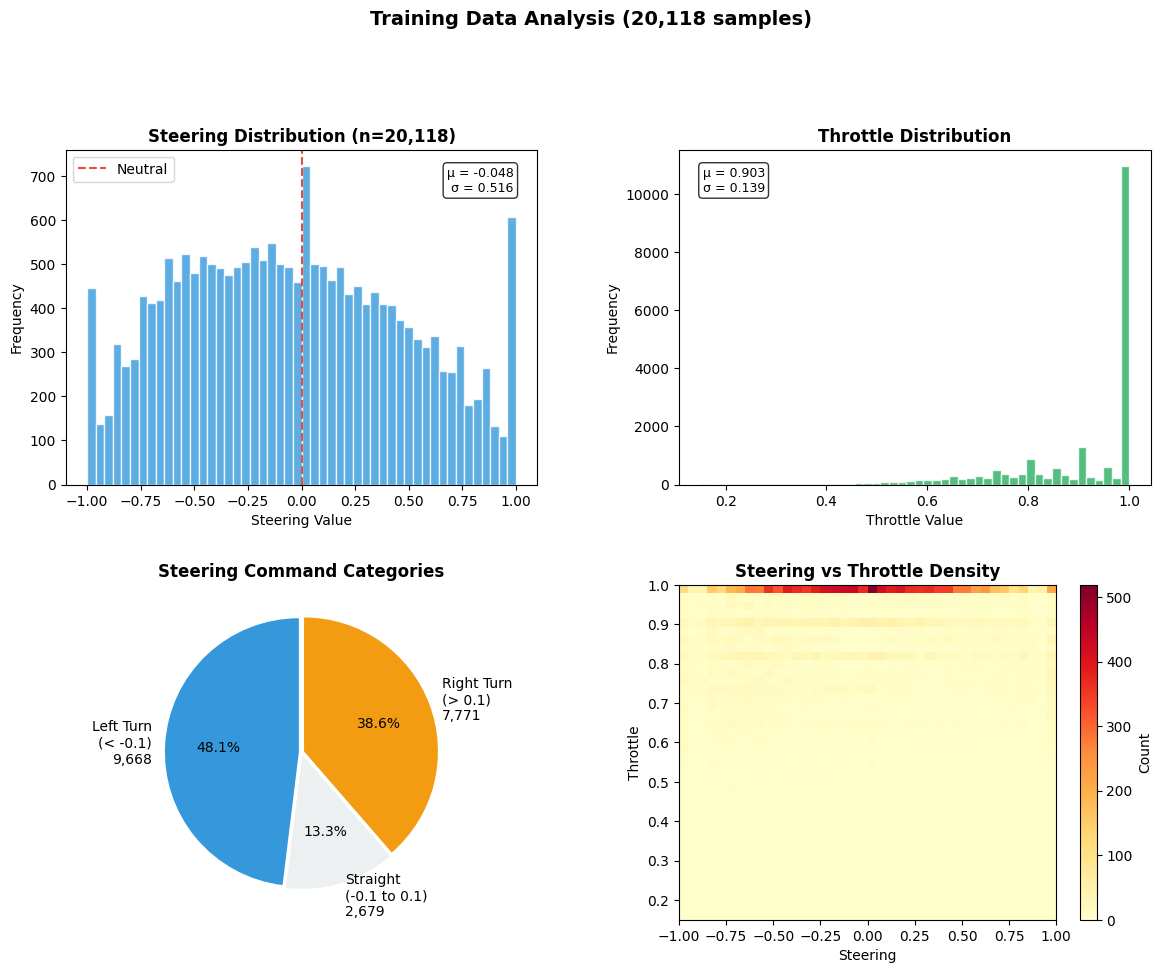

In [801]:
# 6

#!/usr/bin/env python3
"""Training Data Distribution Analysis"""

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import numpy as np

# Load data
df = pd.read_csv('/Users/grmim/Dev/py/final/dataset/labels.csv')

fig = plt.figure(figsize=(14, 10))
gs = gridspec.GridSpec(2, 2, hspace=0.3, wspace=0.3)

# 1. Steering Distribution Histogram
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(df['steering'], bins=50, color='#3498DB', edgecolor='white', alpha=0.8)
ax1.axvline(x=0, color='#E74C3C', linestyle='--', label='Neutral')
ax1.set_xlabel('Steering Value')
ax1.set_ylabel('Frequency')
ax1.set_title('Steering Distribution (n={:,})'.format(len(df)), fontweight='bold')
ax1.legend()

stats_text = f'μ = {df["steering"].mean():.3f}\nσ = {df["steering"].std():.3f}'
ax1.text(0.95, 0.95, stats_text, transform=ax1.transAxes, ha='right', va='top',
         fontsize=9, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# 2. Throttle Distribution Histogram
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(df['throttle'], bins=50, color='#27AE60', edgecolor='white', alpha=0.8)
ax2.set_xlabel('Throttle Value')
ax2.set_ylabel('Frequency')
ax2.set_title('Throttle Distribution', fontweight='bold')

stats_text = f'μ = {df["throttle"].mean():.3f}\nσ = {df["throttle"].std():.3f}'
ax2.text(0.05, 0.95, stats_text, transform=ax2.transAxes, ha='left', va='top',
         fontsize=9, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# 3. Steering Category Pie Chart
ax3 = fig.add_subplot(gs[1, 0])
left = len(df[df['steering'] < -0.1])
straight = len(df[(df['steering'] >= -0.1) & (df['steering'] <= 0.1)])
right = len(df[df['steering'] > 0.1])

sizes = [left, straight, right]
labels = [f'Left Turn\n(< -0.1)\n{left:,}', 
          f'Straight\n(-0.1 to 0.1)\n{straight:,}', 
          f'Right Turn\n(> 0.1)\n{right:,}']
colors_pie = ['#3498DB', '#ECF0F1', '#F39C12']
explode = (0.02, 0.02, 0.02)

ax3.pie(sizes, explode=explode, labels=labels, colors=colors_pie, autopct='%1.1f%%',
        shadow=False, startangle=90)
ax3.set_title('Steering Command Categories', fontweight='bold')

# 4. 2D Density Plot (Steering vs Throttle)
ax4 = fig.add_subplot(gs[1, 1])
h = ax4.hist2d(df['steering'], df['throttle'], bins=40, cmap='YlOrRd')
plt.colorbar(h[3], ax=ax4, label='Count')
ax4.set_xlabel('Steering')
ax4.set_ylabel('Throttle')
ax4.set_title('Steering vs Throttle Density', fontweight='bold')

fig.suptitle('Training Data Analysis ({:,} samples)'.format(len(df)), 
             fontsize=14, fontweight='bold', y=1.02)

plt.show()

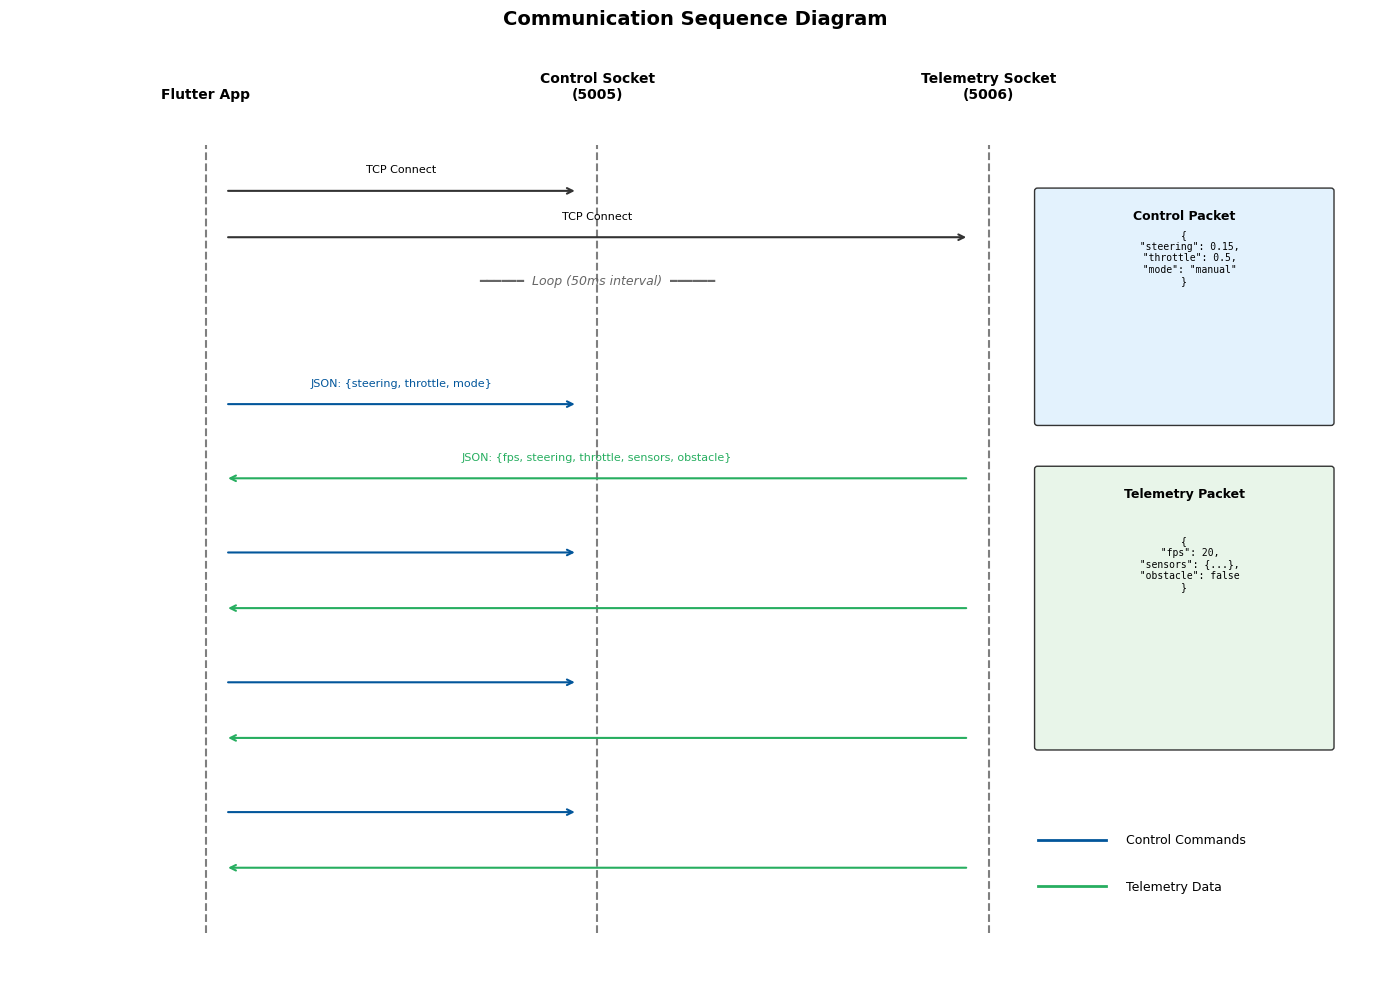

In [802]:
# 7

#!/usr/bin/env python3
"""Communication Sequence Diagram"""

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

COLORS = {'flutter': '#02569B', 'success': '#27AE60', 'warning': '#F39C12'}

fig, ax = plt.subplots(figsize=(14, 10))
ax.set_xlim(0, 14)
ax.set_ylim(0, 10)
ax.axis('off')
ax.set_title('Communication Sequence Diagram', fontsize=14, fontweight='bold', pad=20)

# Lifelines
entities = [
    (2, 'Flutter App'),
    (6, 'Control Socket\n(5005)'),
    (10, 'Telemetry Socket\n(5006)'),
]

for x, name in entities:
    ax.text(x, 9.5, name, ha='center', fontsize=10, fontweight='bold')
    ax.plot([x, x], [0.5, 9], 'k--', alpha=0.5)

# Connection phase
y = 8.5
ax.annotate('', xy=(6-0.2, y), xytext=(2+0.2, y),
           arrowprops=dict(arrowstyle='->', color='#333', lw=1.5))
ax.text(4, y+0.2, 'TCP Connect', fontsize=8, ha='center')

y -= 0.5
ax.annotate('', xy=(10-0.2, y), xytext=(2+0.2, y),
           arrowprops=dict(arrowstyle='->', color='#333', lw=1.5))
ax.text(6, y+0.2, 'TCP Connect', fontsize=8, ha='center')

# Loop indicator
y -= 1
ax.text(6, y+0.5, '━━━━━━  Loop (50ms interval)  ━━━━━━', ha='center', fontsize=9, style='italic', color='#666')

# Control commands
y -= 0.8
ax.annotate('', xy=(6-0.2, y), xytext=(2+0.2, y),
           arrowprops=dict(arrowstyle='->', color=COLORS['flutter'], lw=1.5))
ax.text(4, y+0.2, 'JSON: {steering, throttle, mode}', fontsize=8, ha='center', color=COLORS['flutter'])

# Telemetry response
y -= 0.8
ax.annotate('', xy=(2+0.2, y), xytext=(10-0.2, y),
           arrowprops=dict(arrowstyle='->', color=COLORS['success'], lw=1.5))
ax.text(6, y+0.2, 'JSON: {fps, steering, throttle, sensors, obstacle}', fontsize=8, ha='center', color=COLORS['success'])

# More loops
for i in range(3):
    y -= 0.8
    ax.annotate('', xy=(6-0.2, y), xytext=(2+0.2, y),
               arrowprops=dict(arrowstyle='->', color=COLORS['flutter'], lw=1.5))
    y -= 0.6
    ax.annotate('', xy=(2+0.2, y), xytext=(10-0.2, y),
               arrowprops=dict(arrowstyle='->', color=COLORS['success'], lw=1.5))

# Legend
legend_y = 1.5
ax.plot([10.5, 11.2], [legend_y, legend_y], color=COLORS['flutter'], lw=2)
ax.text(11.4, legend_y, 'Control Commands', fontsize=9, va='center')
ax.plot([10.5, 11.2], [legend_y-0.5, legend_y-0.5], color=COLORS['success'], lw=2)
ax.text(11.4, legend_y-0.5, 'Telemetry Data', fontsize=9, va='center')

# Data format boxes
ctrl_box = FancyBboxPatch((10.5, 6), 3, 2.5, boxstyle="round,pad=0.03",
                           facecolor='#e3f2fd', edgecolor='#333', linewidth=1)
ax.add_patch(ctrl_box)
ax.text(12, 8.2, 'Control Packet', fontsize=9, ha='center', fontweight='bold')
ax.text(12, 7.5, '{\n  "steering": 0.15,\n  "throttle": 0.5,\n  "mode": "manual"\n}', 
        fontsize=7, ha='center', fontfamily='monospace')

tele_box = FancyBboxPatch((10.5, 2.5), 3, 3, boxstyle="round,pad=0.03",
                           facecolor='#e8f5e9', edgecolor='#333', linewidth=1)
ax.add_patch(tele_box)
ax.text(12, 5.2, 'Telemetry Packet', fontsize=9, ha='center', fontweight='bold')
ax.text(12, 4.2, '{\n  "fps": 20,\n  "sensors": {...},\n  "obstacle": false\n}', 
        fontsize=7, ha='center', fontfamily='monospace')

plt.tight_layout()
plt.show()

Matplotlib is building the font cache; this may take a moment.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
f

IEEE-compliant diagrams saved:
  - communication_sequence_ieee.png (600 DPI)
  - communication_sequence_ieee.tiff (600 DPI)

Dimensions: 7.16 x 5.5 inches (two-column width)
Approximate pixel dimensions: 4296 x 3300

IEEE compliance notes:
  - Font: Liberation Serif, 6-9pt
  - Line thickness: ≥1.0pt
  - Grayscale-friendly design
  - Clear entity boxes and loop boundaries
  - Use caption: 'Fig. X. Communication sequence diagram'


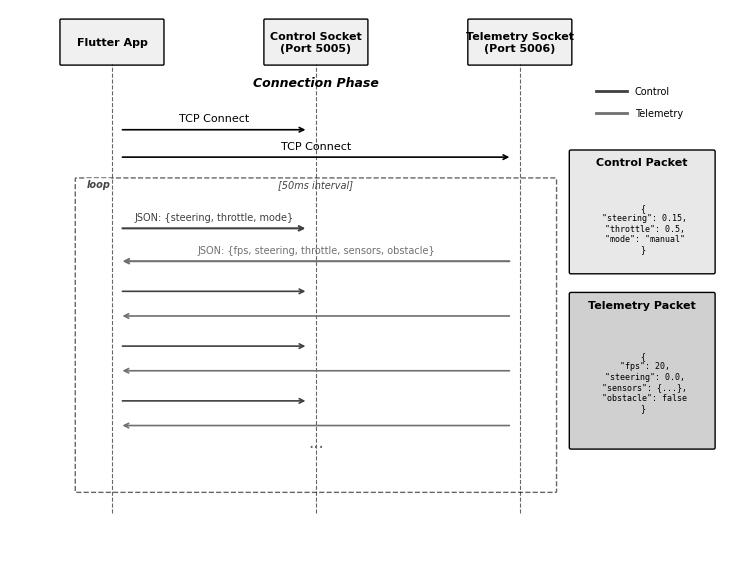

In [1]:
#!/usr/bin/env python3
"""
Communication Sequence Diagram
IEEE-Compliant Formatting

IEEE Guidelines Applied:
- Font: Liberation Serif (metrically compatible with Times New Roman)
- Font size: 8-10 points for labels
- Line thickness: minimum 1.0 points
- Two column width: 7.16 inches (182 mm)
- Resolution: 600 DPI for line art
- Grayscale-friendly design
- No title in figure (use caption below)
"""

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import matplotlib.font_manager as fm

# Reload font manager to ensure Liberation Serif is available
fm._load_fontmanager(try_read_cache=False)

# IEEE-compliant settings
plt.rcParams['font.family'] = 'Liberation Serif'
plt.rcParams['font.size'] = 8
plt.rcParams['axes.linewidth'] = 1.0
plt.rcParams['lines.linewidth'] = 1.0

# Grayscale-friendly colors with good contrast
COLORS = {
    'flutter': '#404040',      # Dark gray for control commands
    'success': '#707070',      # Medium gray for telemetry
    'box_ctrl': '#e8e8e8',     # Light gray for control box
    'box_tele': '#d0d0d0',     # Slightly darker for telemetry box
    'line': '#000000',         # Black for arrows
    'text': '#000000',         # Black text
}

# IEEE two-column width figure
fig_width = 7.16  # inches
fig_height = 5.5  # inches - compact for publication

fig, ax = plt.subplots(figsize=(fig_width, fig_height))
ax.set_xlim(0, 14)
ax.set_ylim(0, 10)
ax.axis('off')

# No title - IEEE uses captions below figures

# Lifelines with clearer labels
entities = [
    (2, 'Flutter App'),
    (6, 'Control Socket\n(Port 5005)'),
    (10, 'Telemetry Socket\n(Port 5006)'),
]

for x, name in entities:
    # Entity boxes at top
    box = FancyBboxPatch((x-1, 9.0), 2, 0.8, boxstyle="round,pad=0.02",
                         facecolor='#f0f0f0', edgecolor='#000000', linewidth=1.0)
    ax.add_patch(box)
    ax.text(x, 9.4, name, ha='center', va='center', fontsize=8, fontweight='bold',
            family='Liberation Serif')
    # Dashed lifeline
    ax.plot([x, x], [0.8, 9.0], 'k--', alpha=0.6, linewidth=0.8)

# Connection phase header
y = 8.3
ax.text(6, y + 0.3, 'Connection Phase', fontsize=9, ha='center', 
        fontweight='bold', family='Liberation Serif', style='italic')

# TCP Connect arrows
y = 7.8
ax.annotate('', xy=(6-0.15, y), xytext=(2+0.15, y),
           arrowprops=dict(arrowstyle='->', color=COLORS['line'], lw=1.2))
ax.text(4, y+0.15, 'TCP Connect', fontsize=8, ha='center', family='Liberation Serif')

y -= 0.5
ax.annotate('', xy=(10-0.15, y), xytext=(2+0.15, y),
           arrowprops=dict(arrowstyle='->', color=COLORS['line'], lw=1.2))
ax.text(6, y+0.15, 'TCP Connect', fontsize=8, ha='center', family='Liberation Serif')

# Loop indicator with clear boundary
y -= 0.7
loop_top = y + 0.3
loop_bottom = 1.2
# Draw loop box
loop_box = FancyBboxPatch((1.3, loop_bottom), 9.4, loop_top - loop_bottom, 
                           boxstyle="round,pad=0.02",
                           facecolor='none', edgecolor='#666666', 
                           linewidth=1.0, linestyle='--')
ax.add_patch(loop_box)
ax.text(1.5, loop_top - 0.15, 'loop', fontsize=7, family='Liberation Serif',
        style='italic', color='#444444', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.1', facecolor='white', edgecolor='none'))
ax.text(6, loop_top - 0.15, '[50ms interval]', fontsize=7, ha='center',
        family='Liberation Serif', style='italic', color='#444444')

# Control command (first)
y -= 0.6
ax.annotate('', xy=(6-0.15, y), xytext=(2+0.15, y),
           arrowprops=dict(arrowstyle='->', color=COLORS['flutter'], lw=1.5))
ax.text(4, y+0.15, 'JSON: {steering, throttle, mode}', fontsize=7, 
        ha='center', family='Liberation Serif', color=COLORS['flutter'])

# Telemetry response (first)
y -= 0.6
ax.annotate('', xy=(2+0.15, y), xytext=(10-0.15, y),
           arrowprops=dict(arrowstyle='->', color=COLORS['success'], lw=1.5))
ax.text(6, y+0.15, 'JSON: {fps, steering, throttle, sensors, obstacle}', 
        fontsize=7, ha='center', family='Liberation Serif', color=COLORS['success'])

# Additional loop iterations (simplified representation)
for i in range(3):
    y -= 0.55
    ax.annotate('', xy=(6-0.15, y), xytext=(2+0.15, y),
               arrowprops=dict(arrowstyle='->', color=COLORS['flutter'], lw=1.2))
    y -= 0.45
    ax.annotate('', xy=(2+0.15, y), xytext=(10-0.15, y),
               arrowprops=dict(arrowstyle='->', color=COLORS['success'], lw=1.2))

# Continuation indicator
y -= 0.4
ax.text(6, y, '...', fontsize=12, ha='center', color='#666666')

# Legend - repositioned for clarity
legend_x = 11.5
legend_y = 8.5
ax.plot([legend_x, legend_x + 0.6], [legend_y, legend_y], 
        color=COLORS['flutter'], lw=2)
ax.text(legend_x + 0.75, legend_y, 'Control', fontsize=7, va='center',
        family='Liberation Serif')
ax.plot([legend_x, legend_x + 0.6], [legend_y - 0.4, legend_y - 0.4], 
        color=COLORS['success'], lw=2)
ax.text(legend_x + 0.75, legend_y - 0.4, 'Telemetry', fontsize=7, va='center',
        family='Liberation Serif')

# Data format boxes - more compact and readable
# Control Packet box
ctrl_box = FancyBboxPatch((11, 5.2), 2.8, 2.2, boxstyle="round,pad=0.03",
                           facecolor=COLORS['box_ctrl'], edgecolor='#000000', linewidth=1.0)
ax.add_patch(ctrl_box)
ax.text(12.4, 7.15, 'Control Packet', fontsize=8, ha='center', fontweight='bold',
        family='Liberation Serif')
ctrl_json = '{\n "steering": 0.15,\n "throttle": 0.5,\n "mode": "manual"\n}'
ax.text(12.4, 6.0, ctrl_json, fontsize=6, ha='center', va='center',
        family='monospace', linespacing=1.2)

# Telemetry Packet box
tele_box = FancyBboxPatch((11, 2.0), 2.8, 2.8, boxstyle="round,pad=0.03",
                           facecolor=COLORS['box_tele'], edgecolor='#000000', linewidth=1.0)
ax.add_patch(tele_box)
ax.text(12.4, 4.55, 'Telemetry Packet', fontsize=8, ha='center', fontweight='bold',
        family='Liberation Serif')
tele_json = '{\n "fps": 20,\n "steering": 0.0,\n "sensors": {...},\n "obstacle": false\n}'
ax.text(12.4, 3.2, tele_json, fontsize=6, ha='center', va='center',
        family='monospace', linespacing=1.2)

plt.tight_layout(pad=0.1)

# Save as IEEE-compliant formats
plt.savefig('diagrams/communication_sequence_ieee.png', 
            dpi=600,
            bbox_inches='tight',
            pad_inches=0.02,
            facecolor='white',
            edgecolor='none',
            format='png')

plt.savefig('diagrams/communication_sequence_ieee.tiff', 
            dpi=600,
            bbox_inches='tight',
            pad_inches=0.02,
            facecolor='white',
            edgecolor='none',
            format='tiff')

print("IEEE-compliant diagrams saved:")
print("  - communication_sequence_ieee.png (600 DPI)")
print("  - communication_sequence_ieee.tiff (600 DPI)")
print(f"\nDimensions: {fig_width} x {fig_height} inches (two-column width)")
print(f"Approximate pixel dimensions: {int(fig_width*600)} x {int(fig_height*600)}")
print("\nIEEE compliance notes:")
print("  - Font: Liberation Serif, 6-9pt")
print("  - Line thickness: ≥1.0pt")
print("  - Grayscale-friendly design")
print("  - Clear entity boxes and loop boundaries")
print("  - Use caption: 'Fig. X. Communication sequence diagram'")

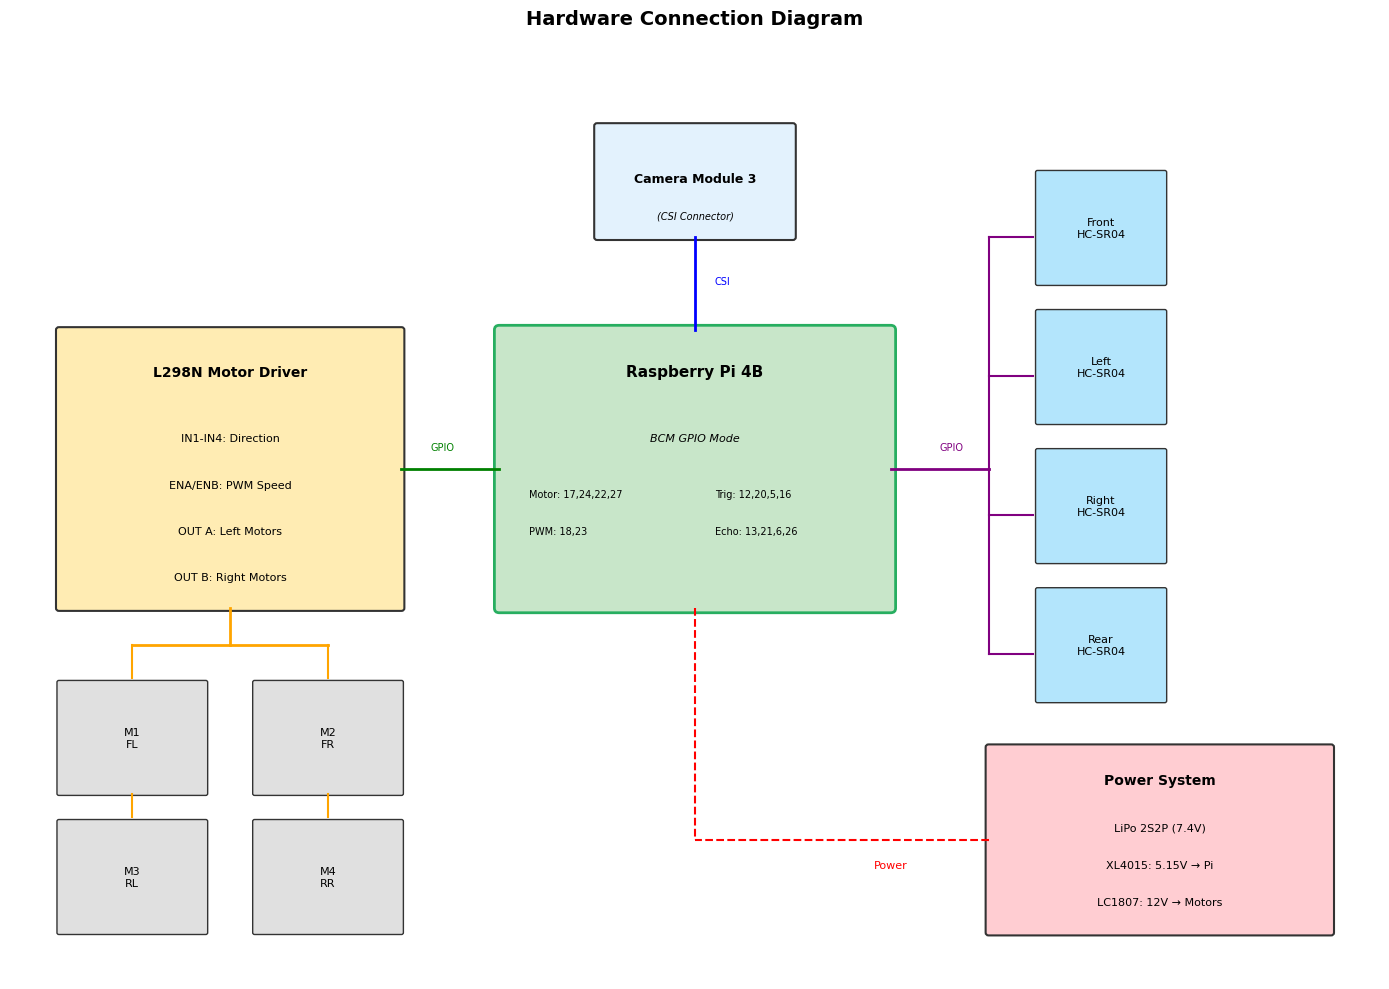

In [803]:
# 8

#!/usr/bin/env python3
"""Hardware Connection Diagram"""

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Rectangle

fig, ax = plt.subplots(figsize=(14, 10))
ax.set_xlim(0, 14)
ax.set_ylim(0, 10)
ax.axis('off')
ax.set_title('Hardware Connection Diagram', fontsize=14, fontweight='bold', pad=20)

# Raspberry Pi (Center)
pi_box = FancyBboxPatch((5, 4), 4, 3, boxstyle="round,pad=0.05",
                         facecolor='#c8e6c9', edgecolor='#27AE60', linewidth=2)
ax.add_patch(pi_box)
ax.text(7, 6.5, 'Raspberry Pi 4B', fontsize=11, fontweight='bold', ha='center')
ax.text(7, 5.8, 'BCM GPIO Mode', fontsize=8, ha='center', style='italic')
ax.text(5.3, 5.2, 'Motor: 17,24,22,27', fontsize=7)
ax.text(5.3, 4.8, 'PWM: 18,23', fontsize=7)
ax.text(7.2, 5.2, 'Trig: 12,20,5,16', fontsize=7)
ax.text(7.2, 4.8, 'Echo: 13,21,6,26', fontsize=7)

# Camera Module (Top)
cam_box = FancyBboxPatch((6, 8), 2, 1.2, boxstyle="round,pad=0.03",
                          facecolor='#e3f2fd', edgecolor='#333', linewidth=1.5)
ax.add_patch(cam_box)
ax.text(7, 8.6, 'Camera Module 3', fontsize=9, ha='center', fontweight='bold')
ax.text(7, 8.2, '(CSI Connector)', fontsize=7, ha='center', style='italic')

# L298N Motor Driver (Left)
motor_box = FancyBboxPatch((0.5, 4), 3.5, 3, boxstyle="round,pad=0.03",
                            facecolor='#ffecb3', edgecolor='#333', linewidth=1.5)
ax.add_patch(motor_box)
ax.text(2.25, 6.5, 'L298N Motor Driver', fontsize=10, ha='center', fontweight='bold')
ax.text(2.25, 5.8, 'IN1-IN4: Direction', fontsize=8, ha='center')
ax.text(2.25, 5.3, 'ENA/ENB: PWM Speed', fontsize=8, ha='center')
ax.text(2.25, 4.8, 'OUT A: Left Motors', fontsize=8, ha='center')
ax.text(2.25, 4.3, 'OUT B: Right Motors', fontsize=8, ha='center')

# DC Motors (Bottom Left)
motor_positions = [(0.5, 2, 'M1\nFL'), (2.5, 2, 'M2\nFR'), (0.5, 0.5, 'M3\nRL'), (2.5, 0.5, 'M4\nRR')]
for x, y, label in motor_positions:
    m_box = FancyBboxPatch((x, y), 1.5, 1.2, boxstyle="round,pad=0.02",
                            facecolor='#e0e0e0', edgecolor='#333', linewidth=1)
    ax.add_patch(m_box)
    ax.text(x + 0.75, y + 0.6, label, fontsize=8, ha='center', va='center')

# Ultrasonic Sensors (Right)
sensors = [
    (10.5, 7.5, 'Front\nHC-SR04'),
    (10.5, 6, 'Left\nHC-SR04'),
    (10.5, 4.5, 'Right\nHC-SR04'),
    (10.5, 3, 'Rear\nHC-SR04'),
]
for x, y, text in sensors:
    sensor_box = FancyBboxPatch((x, y), 1.3, 1.2, boxstyle="round,pad=0.02",
                                 facecolor='#b3e5fc', edgecolor='#333', linewidth=1)
    ax.add_patch(sensor_box)
    ax.text(x + 0.65, y + 0.6, text, fontsize=8, ha='center', va='center')

# Power System (Bottom Right)
power_box = FancyBboxPatch((10, 0.5), 3.5, 2, boxstyle="round,pad=0.03",
                            facecolor='#ffcdd2', edgecolor='#333', linewidth=1.5)
ax.add_patch(power_box)
ax.text(11.75, 2.1, 'Power System', fontsize=10, ha='center', fontweight='bold')
ax.text(11.75, 1.6, 'LiPo 2S2P (7.4V)', fontsize=8, ha='center')
ax.text(11.75, 1.2, 'XL4015: 5.15V → Pi', fontsize=8, ha='center')
ax.text(11.75, 0.8, 'LC1807: 12V → Motors', fontsize=8, ha='center')

# Connection lines
ax.plot([7, 7], [7, 8], 'b-', lw=2)
ax.text(7.2, 7.5, 'CSI', fontsize=7, color='blue')

ax.plot([5, 4], [5.5, 5.5], 'g-', lw=2)
ax.text(4.3, 5.7, 'GPIO', fontsize=7, color='green')

ax.plot([2.25, 2.25], [4, 3.6], 'orange', lw=2)
ax.plot([1.25, 3.25], [3.6, 3.6], 'orange', lw=2)
ax.plot([1.25, 1.25], [3.6, 3.25], 'orange', lw=1.5)
ax.plot([3.25, 3.25], [3.6, 3.25], 'orange', lw=1.5)
ax.plot([1.25, 1.25], [2, 1.75], 'orange', lw=1.5)
ax.plot([3.25, 3.25], [2, 1.75], 'orange', lw=1.5)

ax.plot([9, 10], [5.5, 5.5], 'purple', lw=2)
ax.plot([10, 10], [5.5, 8], 'purple', lw=1.5)
ax.plot([10, 10], [5.5, 3.5], 'purple', lw=1.5)
ax.plot([10, 10.45], [3.5, 3.5], 'purple', lw=1.5)
ax.plot([10, 10.45], [5, 5], 'purple', lw=1.5)
ax.plot([10, 10.45], [6.5, 6.5], 'purple', lw=1.5)
ax.plot([10, 10.45], [8, 8], 'purple', lw=1.5)
ax.text(9.5, 5.7, 'GPIO', fontsize=7, color='purple')

ax.plot([7, 7], [4, 1.5], 'r--', lw=1.5)
ax.plot([10, 7], [1.5, 1.5], 'r--', lw=1.5)
ax.text(9, 1.2, 'Power', fontsize=8, color='red', ha='center')

plt.tight_layout()
plt.show()

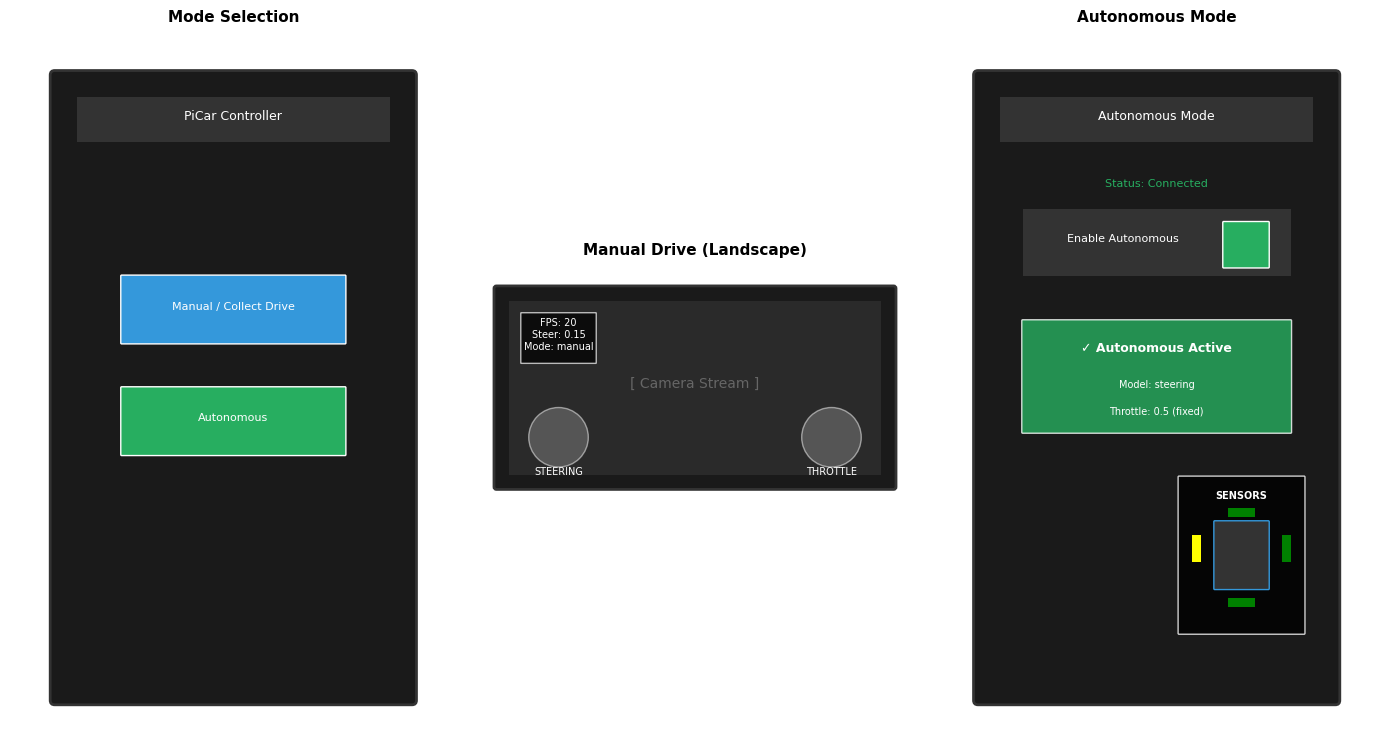

In [5]:
# 9

#!/usr/bin/env python3
"""Flutter App UI Wireframes"""

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Rectangle, Circle

fig = plt.figure(figsize=(14, 8))

# Mode Selection Screen
ax1 = fig.add_subplot(1, 3, 1)
ax1.set_xlim(0, 10)
ax1.set_ylim(0, 16)
ax1.set_aspect('equal')
ax1.axis('off')
ax1.set_title('Mode Selection', fontsize=11, fontweight='bold')

phone = FancyBboxPatch((1, 1), 8, 14, boxstyle="round,pad=0.1",
                        facecolor='#1a1a1a', edgecolor='#333', linewidth=2)
ax1.add_patch(phone)

ax1.add_patch(Rectangle((1.5, 13.5), 7, 1, facecolor='#333'))
ax1.text(5, 14, 'PiCar Controller', color='white', ha='center', fontsize=9)

btn1 = FancyBboxPatch((2.5, 9), 5, 1.5, boxstyle="round,pad=0.02",
                       facecolor='#3498DB', edgecolor='white', linewidth=1)
ax1.add_patch(btn1)
ax1.text(5, 9.75, 'Manual / Collect Drive', color='white', ha='center', fontsize=8)

btn2 = FancyBboxPatch((2.5, 6.5), 5, 1.5, boxstyle="round,pad=0.02",
                       facecolor='#27AE60', edgecolor='white', linewidth=1)
ax1.add_patch(btn2)
ax1.text(5, 7.25, 'Autonomous', color='white', ha='center', fontsize=8)

# Manual Drive Screen
ax2 = fig.add_subplot(1, 3, 2)
ax2.set_xlim(0, 18)
ax2.set_ylim(0, 10)
ax2.set_aspect('equal')
ax2.axis('off')
ax2.set_title('Manual Drive (Landscape)', fontsize=11, fontweight='bold')

phone2 = FancyBboxPatch((1, 1), 16, 8, boxstyle="round,pad=0.1",
                         facecolor='#1a1a1a', edgecolor='#333', linewidth=2)
ax2.add_patch(phone2)

ax2.add_patch(Rectangle((1.5, 1.5), 15, 7, facecolor='#2a2a2a'))
ax2.text(9, 5, '[ Camera Stream ]', color='#666', ha='center', fontsize=10)

hud = FancyBboxPatch((2, 6), 3, 2, boxstyle="round,pad=0.02",
                      facecolor='black', edgecolor='white', linewidth=1, alpha=0.7)
ax2.add_patch(hud)
ax2.text(3.5, 7.5, 'FPS: 20', color='white', fontsize=7, ha='center')
ax2.text(3.5, 7, 'Steer: 0.15', color='white', fontsize=7, ha='center')
ax2.text(3.5, 6.5, 'Mode: manual', color='white', fontsize=7, ha='center')

circle1 = Circle((3.5, 3), 1.2, facecolor='gray', edgecolor='white', alpha=0.5)
ax2.add_patch(circle1)
ax2.text(3.5, 1.5, 'STEERING', color='white', fontsize=7, ha='center')

circle2 = Circle((14.5, 3), 1.2, facecolor='gray', edgecolor='white', alpha=0.5)
ax2.add_patch(circle2)
ax2.text(14.5, 1.5, 'THROTTLE', color='white', fontsize=7, ha='center')

# Autonomous Screen
ax3 = fig.add_subplot(1, 3, 3)
ax3.set_xlim(0, 10)
ax3.set_ylim(0, 16)
ax3.set_aspect('equal')
ax3.axis('off')
ax3.set_title('Autonomous Mode', fontsize=11, fontweight='bold')

phone3 = FancyBboxPatch((1, 1), 8, 14, boxstyle="round,pad=0.1",
                         facecolor='#1a1a1a', edgecolor='#333', linewidth=2)
ax3.add_patch(phone3)

ax3.add_patch(Rectangle((1.5, 13.5), 7, 1, facecolor='#333'))
ax3.text(5, 14, 'Autonomous Mode', color='white', ha='center', fontsize=9)

ax3.text(5, 12.5, 'Status: Connected', color='#27AE60', ha='center', fontsize=8)

ax3.add_patch(Rectangle((2, 10.5), 6, 1.5, facecolor='#333'))
ax3.text(3, 11.25, 'Enable Autonomous', color='white', fontsize=8)
toggle = FancyBboxPatch((6.5, 10.7), 1, 1, boxstyle="round,pad=0.02",
                         facecolor='#27AE60', edgecolor='white')
ax3.add_patch(toggle)

card = FancyBboxPatch((2, 7), 6, 2.5, boxstyle="round,pad=0.02",
                       facecolor='#27AE60', alpha=0.8, edgecolor='white')
ax3.add_patch(card)
ax3.text(5, 8.8, '✓ Autonomous Active', color='white', ha='center', fontsize=9, fontweight='bold')
ax3.text(5, 8, 'Model: steering', color='white', ha='center', fontsize=7)
ax3.text(5, 7.4, 'Throttle: 0.5 (fixed)', color='white', ha='center', fontsize=7)

sensor_box = FancyBboxPatch((5.5, 2.5), 2.8, 3.5, boxstyle="round,pad=0.02",
                             facecolor='black', alpha=0.8, edgecolor='white', linewidth=1)
ax3.add_patch(sensor_box)
ax3.text(6.9, 5.5, 'SENSORS', color='white', ha='center', fontsize=7, fontweight='bold')

car = FancyBboxPatch((6.3, 3.5), 1.2, 1.5, boxstyle="round,pad=0.02",
                      facecolor='#333', edgecolor='#3498DB', linewidth=1)
ax3.add_patch(car)

ax3.add_patch(Rectangle((6.6, 5.1), 0.6, 0.2, facecolor='green'))
ax3.add_patch(Rectangle((5.8, 4.1), 0.2, 0.6, facecolor='yellow'))
ax3.add_patch(Rectangle((7.8, 4.1), 0.2, 0.6, facecolor='green'))
ax3.add_patch(Rectangle((6.6, 3.1), 0.6, 0.2, facecolor='green'))

plt.tight_layout()
plt.show()

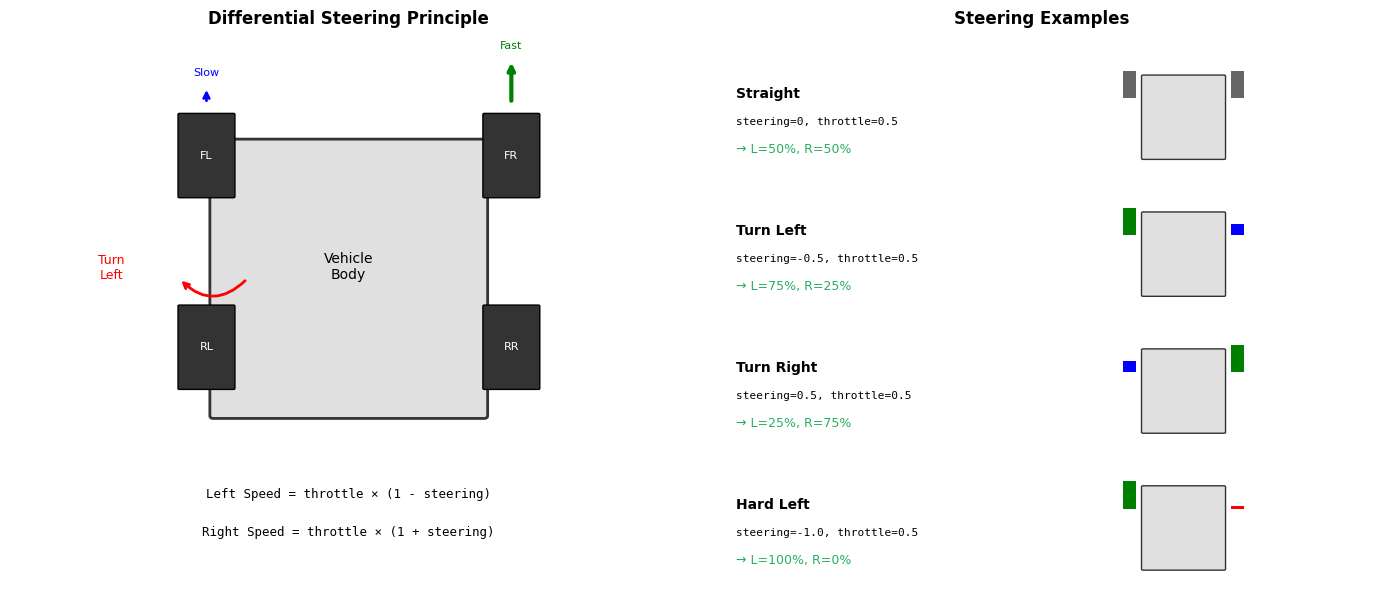

In [805]:
# 10

#!/usr/bin/env python3
"""Differential Steering and Motor Control Diagram"""

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Rectangle

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left: Differential steering explanation
ax1.set_xlim(0, 10)
ax1.set_ylim(0, 10)
ax1.axis('off')
ax1.set_title('Differential Steering Principle', fontsize=12, fontweight='bold')

car = FancyBboxPatch((3, 3), 4, 5, boxstyle="round,pad=0.05",
                      facecolor='#e0e0e0', edgecolor='#333', linewidth=2)
ax1.add_patch(car)
ax1.text(5, 5.5, 'Vehicle\nBody', ha='center', fontsize=10)

wheels = [(2.5, 7, 'FL'), (7, 7, 'FR'), (2.5, 3.5, 'RL'), (7, 3.5, 'RR')]
for x, y, label in wheels:
    wheel = FancyBboxPatch((x, y), 0.8, 1.5, boxstyle="round,pad=0.02",
                            facecolor='#333', edgecolor='black', linewidth=1)
    ax1.add_patch(wheel)
    ax1.text(x + 0.4, y + 0.75, label, ha='center', va='center', color='white', fontsize=8)

ax1.annotate('', xy=(2.9, 9), xytext=(2.9, 8.7),
            arrowprops=dict(arrowstyle='->', color='blue', lw=2))
ax1.text(2.9, 9.2, 'Slow', ha='center', fontsize=8, color='blue')

ax1.annotate('', xy=(7.4, 9.5), xytext=(7.4, 8.7),
            arrowprops=dict(arrowstyle='->', color='green', lw=3))
ax1.text(7.4, 9.7, 'Fast', ha='center', fontsize=8, color='green')

ax1.annotate('', xy=(2.5, 5.5), xytext=(3.5, 5.5),
            arrowprops=dict(arrowstyle='->', color='red', lw=2, 
                           connectionstyle='arc3,rad=-0.5'))
ax1.text(1.5, 5.5, 'Turn\nLeft', ha='center', fontsize=9, color='red')

ax1.text(5, 1.5, 'Left Speed = throttle × (1 - steering)', fontsize=9, ha='center',
         fontfamily='monospace')
ax1.text(5, 0.8, 'Right Speed = throttle × (1 + steering)', fontsize=9, ha='center',
         fontfamily='monospace')

# Right: Example scenarios
ax2.set_xlim(0, 10)
ax2.set_ylim(0, 10)
ax2.axis('off')
ax2.set_title('Steering Examples', fontsize=12, fontweight='bold')

scenarios = [
    (0.5, 8, 'Straight', 'steering=0, throttle=0.5', 'L=50%, R=50%', '#666', '#666'),
    (0.5, 5.5, 'Turn Left', 'steering=-0.5, throttle=0.5', 'L=75%, R=25%', 'green', 'blue'),
    (0.5, 3, 'Turn Right', 'steering=0.5, throttle=0.5', 'L=25%, R=75%', 'blue', 'green'),
    (0.5, 0.5, 'Hard Left', 'steering=-1.0, throttle=0.5', 'L=100%, R=0%', 'green', 'red'),
]

for x, y, title, params, result, l_color, r_color in scenarios:
    ax2.text(x, y + 0.8, title, fontsize=10, fontweight='bold')
    ax2.text(x, y + 0.3, params, fontsize=8, fontfamily='monospace')
    ax2.text(x, y - 0.2, f'→ {result}', fontsize=9, color='#27AE60')
    
    mini_x = x + 6
    mini_car = FancyBboxPatch((mini_x, y - 0.3), 1.2, 1.5, boxstyle="round,pad=0.02",
                               facecolor='#e0e0e0', edgecolor='#333', linewidth=1)
    ax2.add_patch(mini_car)
    
    # Wheel indicators (height shows relative speed)
    l_height = 0.5 if 'Left' in title or 'Straight' in title else 0.2
    r_height = 0.5 if 'Right' in title or 'Straight' in title else 0.2
    if 'Hard' in title:
        r_height = 0.05
    
    ax2.add_patch(Rectangle((mini_x - 0.3, y + 0.8), 0.2, l_height, facecolor=l_color))
    ax2.add_patch(Rectangle((mini_x + 1.3, y + 0.8), 0.2, r_height, facecolor=r_color))

plt.tight_layout()
plt.show()

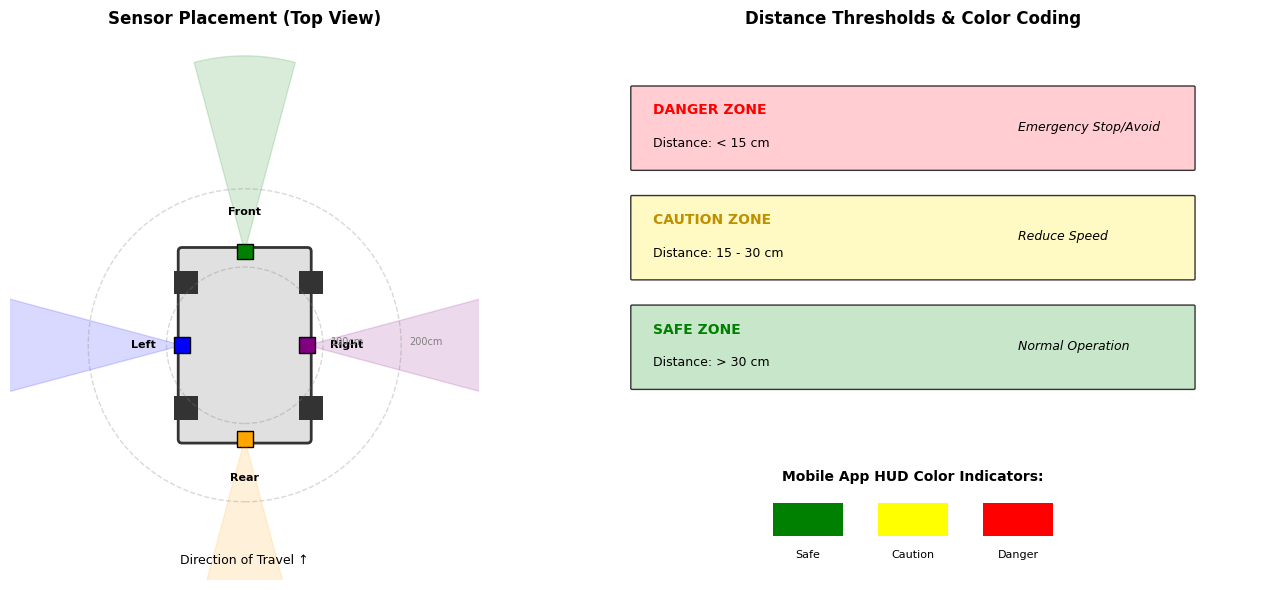

In [806]:
# 11

#!/usr/bin/env python3
"""Ultrasonic Sensor Placement and Coverage Diagram"""

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Rectangle, Wedge, Circle
import numpy as np

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left: Top-down view
ax1.set_xlim(-3, 3)
ax1.set_ylim(-3, 4)
ax1.set_aspect('equal')
ax1.set_title('Sensor Placement (Top View)', fontsize=12, fontweight='bold')
ax1.axis('off')

car = FancyBboxPatch((-0.8, -1.2), 1.6, 2.4, boxstyle="round,pad=0.05",
                      facecolor='#e0e0e0', edgecolor='#333', linewidth=2)
ax1.add_patch(car)

wheel_positions = [(-0.9, 0.8), (0.7, 0.8), (-0.9, -0.8), (0.7, -0.8)]
for wx, wy in wheel_positions:
    wheel = Rectangle((wx, wy-0.15), 0.3, 0.3, facecolor='#333')
    ax1.add_patch(wheel)

sensors = [
    (0, 1.2, 90, 'Front', 'green'),
    (-0.8, 0, 180, 'Left', 'blue'),
    (0.8, 0, 0, 'Right', 'purple'),
    (0, -1.2, 270, 'Rear', 'orange'),
]

for sx, sy, angle, label, color in sensors:
    sensor = Rectangle((sx-0.1, sy-0.1), 0.2, 0.2, facecolor=color, edgecolor='black')
    ax1.add_patch(sensor)
    
    wedge = Wedge((sx, sy), 2.5, angle - 15, angle + 15, 
                   facecolor=color, alpha=0.15, edgecolor=color, linewidth=1)
    ax1.add_patch(wedge)
    
    angle_rad = np.radians(angle)
    lx = sx + 0.5 * np.cos(angle_rad)
    ly = sy + 0.5 * np.sin(angle_rad)
    ax1.text(lx, ly, label, fontsize=8, ha='center', va='center', fontweight='bold')

for d in [1, 2]:
    circle = Circle((0, 0), d, fill=False, linestyle='--', color='gray', alpha=0.3)
    ax1.add_patch(circle)
    ax1.text(d + 0.1, 0, f'{d*100}cm', fontsize=7, color='gray')

ax1.text(0, -2.8, 'Direction of Travel ↑', ha='center', fontsize=9)

# Right: Threshold visualization
ax2.set_xlim(0, 10)
ax2.set_ylim(0, 10)
ax2.axis('off')
ax2.set_title('Distance Thresholds & Color Coding', fontsize=12, fontweight='bold')

thresholds = [
    (1, 7.5, 'DANGER ZONE', '< 15 cm', '#ffcdd2', 'red', 'Emergency Stop/Avoid'),
    (1, 5.5, 'CAUTION ZONE', '15 - 30 cm', '#fff9c4', '#bf8f00', 'Reduce Speed'),
    (1, 3.5, 'SAFE ZONE', '> 30 cm', '#c8e6c9', 'green', 'Normal Operation'),
]

for x, y, zone, dist, color, text_color, action in thresholds:
    bar = FancyBboxPatch((x, y), 8, 1.5, boxstyle="round,pad=0.02",
                          facecolor=color, edgecolor='#333', linewidth=1)
    ax2.add_patch(bar)
    
    ax2.text(x + 0.3, y + 1, zone, fontsize=10, fontweight='bold', color=text_color)
    ax2.text(x + 0.3, y + 0.4, f'Distance: {dist}', fontsize=9)
    ax2.text(x + 5.5, y + 0.7, action, fontsize=9, style='italic')

ax2.text(5, 1.8, 'Mobile App HUD Color Indicators:', fontsize=10, ha='center', fontweight='bold')
for i, (c, label) in enumerate([('green', 'Safe'), ('yellow', 'Caution'), ('red', 'Danger')]):
    ax2.add_patch(Rectangle((3 + i*1.5, 0.8), 1, 0.6, facecolor=c))
    ax2.text(3.5 + i*1.5, 0.4, label, fontsize=8, ha='center')

plt.tight_layout()
plt.show()

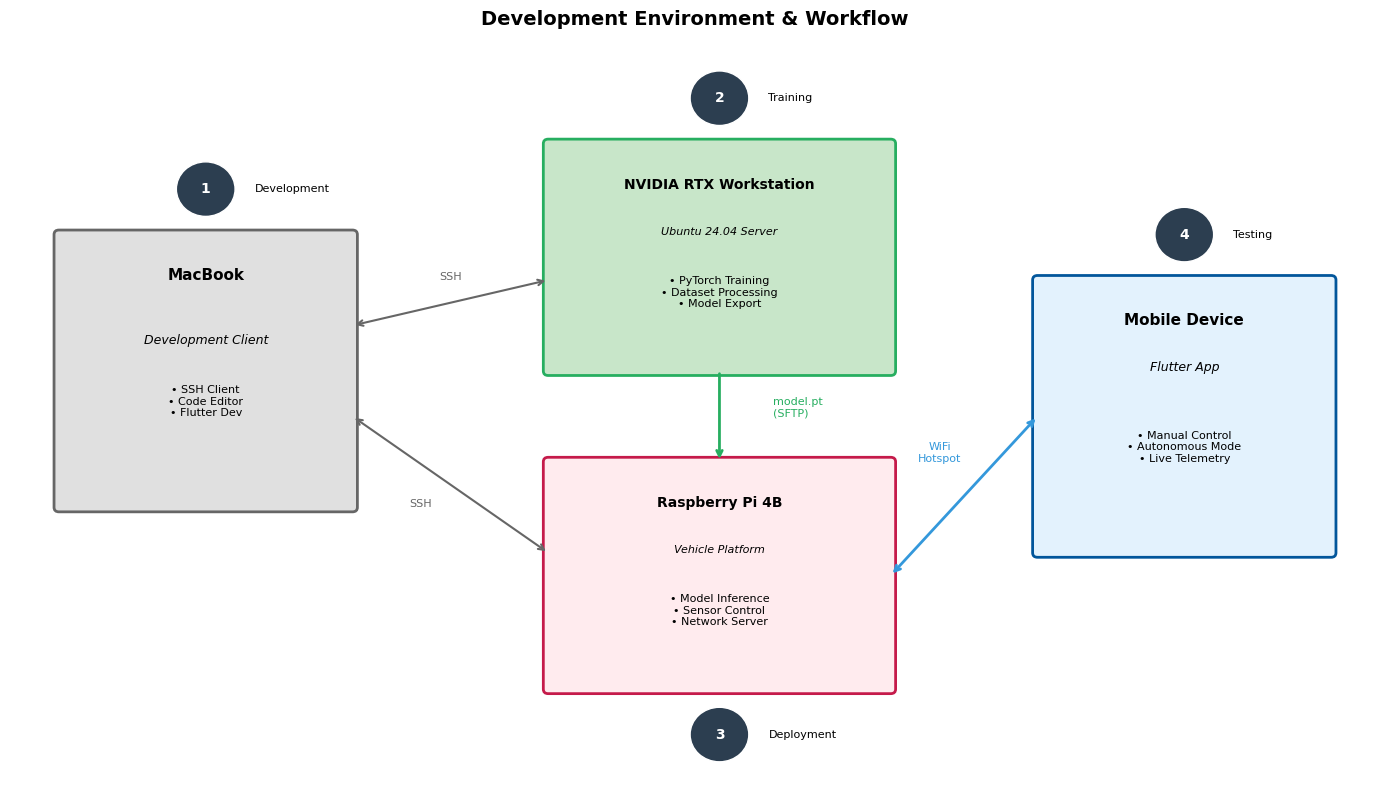

In [807]:
# 12

#!/usr/bin/env python3
"""Development Environment & Workflow Diagram"""

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Circle

fig, ax = plt.subplots(figsize=(14, 8))
ax.set_xlim(0, 14)
ax.set_ylim(0, 8)
ax.axis('off')
ax.set_title('Development Environment & Workflow', fontsize=14, fontweight='bold', pad=20)

# MacBook
mac_box = FancyBboxPatch((0.5, 3), 3, 3, boxstyle="round,pad=0.05",
                          facecolor='#e0e0e0', edgecolor='#666', linewidth=2)
ax.add_patch(mac_box)
ax.text(2, 5.5, 'MacBook', fontsize=11, fontweight='bold', ha='center')
ax.text(2, 4.8, 'Development Client', fontsize=9, ha='center', style='italic')
ax.text(2, 4, '• SSH Client\n• Code Editor\n• Flutter Dev', fontsize=8, ha='center')

# NVIDIA Workstation
nvidia_box = FancyBboxPatch((5.5, 4.5), 3.5, 2.5, boxstyle="round,pad=0.05",
                             facecolor='#c8e6c9', edgecolor='#27AE60', linewidth=2)
ax.add_patch(nvidia_box)
ax.text(7.25, 6.5, 'NVIDIA RTX Workstation', fontsize=10, fontweight='bold', ha='center')
ax.text(7.25, 6, 'Ubuntu 24.04 Server', fontsize=8, ha='center', style='italic')
ax.text(7.25, 5.2, '• PyTorch Training\n• Dataset Processing\n• Model Export', fontsize=8, ha='center')

# Raspberry Pi
pi_box = FancyBboxPatch((5.5, 1), 3.5, 2.5, boxstyle="round,pad=0.05",
                         facecolor='#ffebee', edgecolor='#C51A4A', linewidth=2)
ax.add_patch(pi_box)
ax.text(7.25, 3, 'Raspberry Pi 4B', fontsize=10, fontweight='bold', ha='center')
ax.text(7.25, 2.5, 'Vehicle Platform', fontsize=8, ha='center', style='italic')
ax.text(7.25, 1.7, '• Model Inference\n• Sensor Control\n• Network Server', fontsize=8, ha='center')

# Mobile Device
mobile_box = FancyBboxPatch((10.5, 2.5), 3, 3, boxstyle="round,pad=0.05",
                             facecolor='#e3f2fd', edgecolor='#02569B', linewidth=2)
ax.add_patch(mobile_box)
ax.text(12, 5, 'Mobile Device', fontsize=11, fontweight='bold', ha='center')
ax.text(12, 4.5, 'Flutter App', fontsize=9, ha='center', style='italic')
ax.text(12, 3.5, '• Manual Control\n• Autonomous Mode\n• Live Telemetry', fontsize=8, ha='center')

# Arrows
ax.annotate('', xy=(5.5, 5.5), xytext=(3.5, 5),
           arrowprops=dict(arrowstyle='<->', color='#666', lw=1.5))
ax.text(4.5, 5.5, 'SSH', fontsize=8, ha='center', color='#666')

ax.annotate('', xy=(5.5, 2.5), xytext=(3.5, 4),
           arrowprops=dict(arrowstyle='<->', color='#666', lw=1.5))
ax.text(4.2, 3, 'SSH', fontsize=8, ha='center', color='#666')

ax.annotate('', xy=(7.25, 3.5), xytext=(7.25, 4.5),
           arrowprops=dict(arrowstyle='->', color='#27AE60', lw=2))
ax.text(7.8, 4, 'model.pt\n(SFTP)', fontsize=8, color='#27AE60')

ax.annotate('', xy=(10.5, 4), xytext=(9, 2.25),
           arrowprops=dict(arrowstyle='<->', color='#3498DB', lw=2))
ax.text(9.5, 3.5, 'WiFi\nHotspot', fontsize=8, ha='center', color='#3498DB')

# Workflow numbers
workflow = [
    (2, 6.5, '1', 'Development'),
    (7.25, 7.5, '2', 'Training'),
    (7.25, 0.5, '3', 'Deployment'),
    (12, 6, '4', 'Testing'),
]

for x, y, num, label in workflow:
    circle = Circle((x, y), 0.3, facecolor='#2C3E50', edgecolor='white')
    ax.add_patch(circle)
    ax.text(x, y, num, ha='center', va='center', color='white', fontweight='bold')
    ax.text(x + 0.5, y, label, fontsize=8, va='center')

plt.tight_layout()
plt.show()

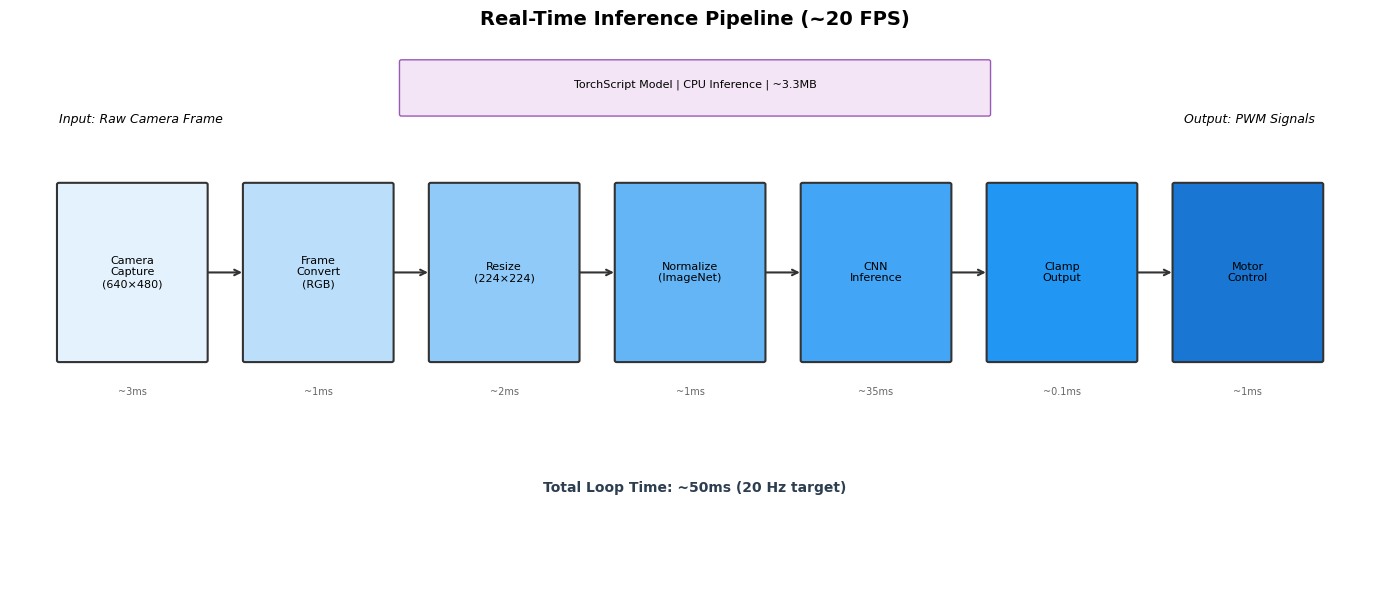

In [ ]:
# 13

#!/usr/bin/env python3
"""Real-Time Inference Pipeline Diagram"""

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(14, 6))
ax.set_xlim(0, 14)
ax.set_ylim(0, 6)
ax.axis('off')
ax.set_title('Real-Time Inference Pipeline (~20 FPS)', fontsize=14, fontweight='bold', pad=20)

steps = [
    ('Camera\nCapture\n(640×480)', '#e3f2fd', '~3ms'),
    ('Frame\nConvert\n(RGB)', '#bbdefb', '~1ms'),
    ('Resize\n(224×224)', '#90caf9', '~2ms'),
    ('Normalize\n(ImageNet)', '#64b5f6', '~1ms'),
    ('CNN\nInference', '#42a5f5', '~35ms'),
    ('Clamp\nOutput', '#2196f3', '~0.1ms'),
    ('Motor\nControl', '#1976d2', '~1ms'),
]

x_start = 0.5
for i, (text, color, time) in enumerate(steps):
    x = x_start + i * 1.9
    box = FancyBboxPatch((x, 2.5), 1.5, 2, boxstyle="round,pad=0.02",
                         facecolor=color, edgecolor='#333', linewidth=1.5)
    ax.add_patch(box)
    ax.text(x + 0.75, 3.5, text, fontsize=8, ha='center', va='center')
    ax.text(x + 0.75, 2.1, time, fontsize=7, ha='center', color='#666')
    
    if i < len(steps) - 1:
        ax.annotate('', xy=(x + 1.9, 3.5), xytext=(x + 1.5, 3.5),
                   arrowprops=dict(arrowstyle='->', color='#333', lw=1.5))

ax.text(7, 1, 'Total Loop Time: ~50ms (20 Hz target)', fontsize=10, ha='center',
        fontweight='bold', color='#2C3E50')

ax.text(0.5, 5.2, 'Input: Raw Camera Frame', fontsize=9, style='italic')
ax.text(12, 5.2, 'Output: PWM Signals', fontsize=9, style='italic')

model_box = FancyBboxPatch((4, 5.3), 6, 0.6, boxstyle="round,pad=0.02",
                            facecolor='#f3e5f5', edgecolor='#9B59B6', linewidth=1)
ax.add_patch(model_box)
ax.text(7, 5.6, 'TorchScript Model | CPU Inference | ~3.3MB', fontsize=8, ha='center')

plt.tight_layout()
plt.show()

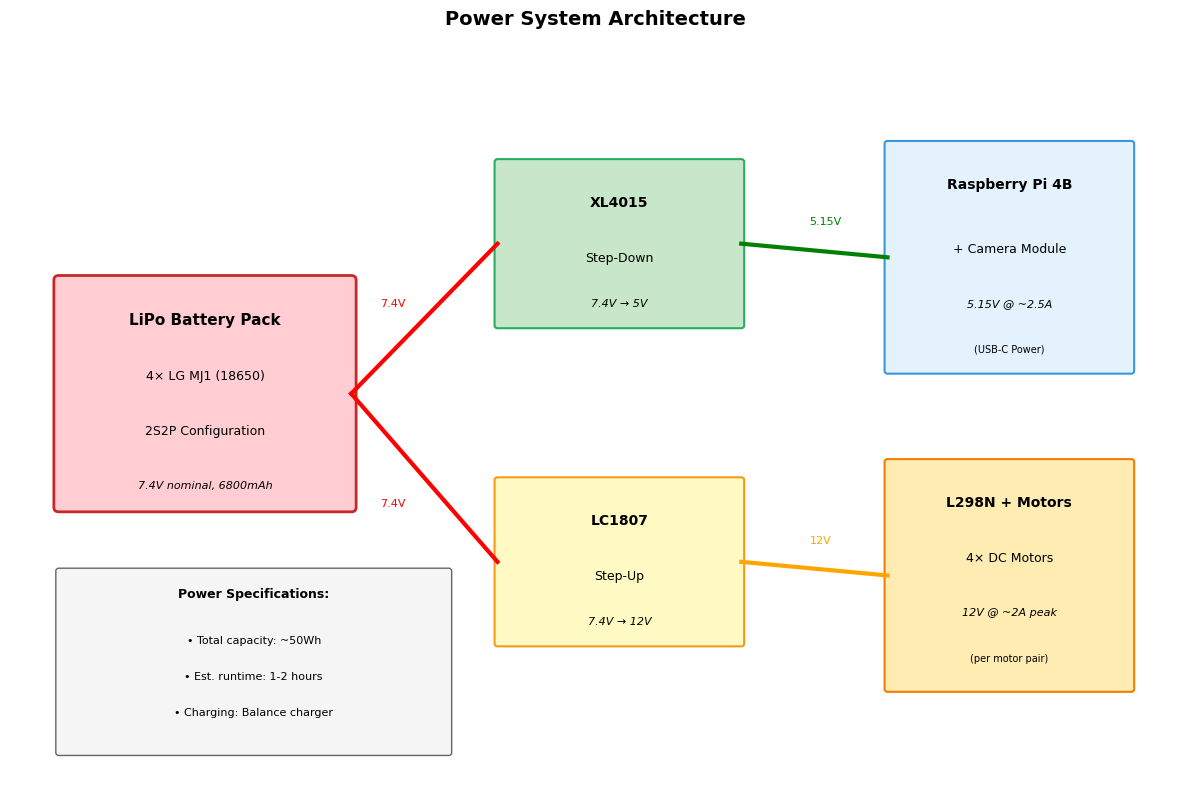

In [809]:
# 14

#!/usr/bin/env python3
"""Power System Architecture Diagram"""

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(12, 8))
ax.set_xlim(0, 12)
ax.set_ylim(0, 8)
ax.axis('off')
ax.set_title('Power System Architecture', fontsize=14, fontweight='bold', pad=20)

# Battery Pack
battery_box = FancyBboxPatch((0.5, 3), 3, 2.5, boxstyle="round,pad=0.05",
                              facecolor='#ffcdd2', edgecolor='#c62828', linewidth=2)
ax.add_patch(battery_box)
ax.text(2, 5, 'LiPo Battery Pack', fontsize=11, fontweight='bold', ha='center')
ax.text(2, 4.4, '4× LG MJ1 (18650)', fontsize=9, ha='center')
ax.text(2, 3.8, '2S2P Configuration', fontsize=9, ha='center')
ax.text(2, 3.2, '7.4V nominal, 6800mAh', fontsize=8, ha='center', style='italic')

# Step-Down (5V)
stepdown_box = FancyBboxPatch((5, 5), 2.5, 1.8, boxstyle="round,pad=0.03",
                               facecolor='#c8e6c9', edgecolor='#27AE60', linewidth=1.5)
ax.add_patch(stepdown_box)
ax.text(6.25, 6.3, 'XL4015', fontsize=10, fontweight='bold', ha='center')
ax.text(6.25, 5.7, 'Step-Down', fontsize=9, ha='center')
ax.text(6.25, 5.2, '7.4V → 5V', fontsize=8, ha='center', style='italic')

# Step-Up (12V)
stepup_box = FancyBboxPatch((5, 1.5), 2.5, 1.8, boxstyle="round,pad=0.03",
                             facecolor='#fff9c4', edgecolor='#F39C12', linewidth=1.5)
ax.add_patch(stepup_box)
ax.text(6.25, 2.8, 'LC1807', fontsize=10, fontweight='bold', ha='center')
ax.text(6.25, 2.2, 'Step-Up', fontsize=9, ha='center')
ax.text(6.25, 1.7, '7.4V → 12V', fontsize=8, ha='center', style='italic')

# Raspberry Pi
pi_box = FancyBboxPatch((9, 4.5), 2.5, 2.5, boxstyle="round,pad=0.03",
                         facecolor='#e3f2fd', edgecolor='#3498DB', linewidth=1.5)
ax.add_patch(pi_box)
ax.text(10.25, 6.5, 'Raspberry Pi 4B', fontsize=10, fontweight='bold', ha='center')
ax.text(10.25, 5.8, '+ Camera Module', fontsize=9, ha='center')
ax.text(10.25, 5.2, '5.15V @ ~2.5A', fontsize=8, ha='center', style='italic')
ax.text(10.25, 4.7, '(USB-C Power)', fontsize=7, ha='center')

# Motor Driver + Motors
motor_box = FancyBboxPatch((9, 1), 2.5, 2.5, boxstyle="round,pad=0.03",
                            facecolor='#ffecb3', edgecolor='#f57c00', linewidth=1.5)
ax.add_patch(motor_box)
ax.text(10.25, 3, 'L298N + Motors', fontsize=10, fontweight='bold', ha='center')
ax.text(10.25, 2.4, '4× DC Motors', fontsize=9, ha='center')
ax.text(10.25, 1.8, '12V @ ~2A peak', fontsize=8, ha='center', style='italic')
ax.text(10.25, 1.3, '(per motor pair)', fontsize=7, ha='center')

# Power lines
ax.plot([3.5, 5], [4.25, 5.9], 'r-', lw=3)
ax.plot([3.5, 5], [4.25, 2.4], 'r-', lw=3)
ax.text(3.8, 5.2, '7.4V', fontsize=8, color='red')
ax.text(3.8, 3, '7.4V', fontsize=8, color='red')

ax.plot([7.5, 9], [5.9, 5.75], 'g-', lw=3)
ax.text(8.2, 6.1, '5.15V', fontsize=8, color='green')

ax.plot([7.5, 9], [2.4, 2.25], 'orange', lw=3)
ax.text(8.2, 2.6, '12V', fontsize=8, color='orange')

# Specifications box
specs_box = FancyBboxPatch((0.5, 0.3), 4, 2, boxstyle="round,pad=0.03",
                            facecolor='#f5f5f5', edgecolor='#666', linewidth=1)
ax.add_patch(specs_box)
ax.text(2.5, 2, 'Power Specifications:', fontsize=9, ha='center', fontweight='bold')
ax.text(2.5, 1.5, '• Total capacity: ~50Wh', fontsize=8, ha='center')
ax.text(2.5, 1.1, '• Est. runtime: 1-2 hours', fontsize=8, ha='center')
ax.text(2.5, 0.7, '• Charging: Balance charger', fontsize=8, ha='center')

plt.tight_layout()
plt.show()

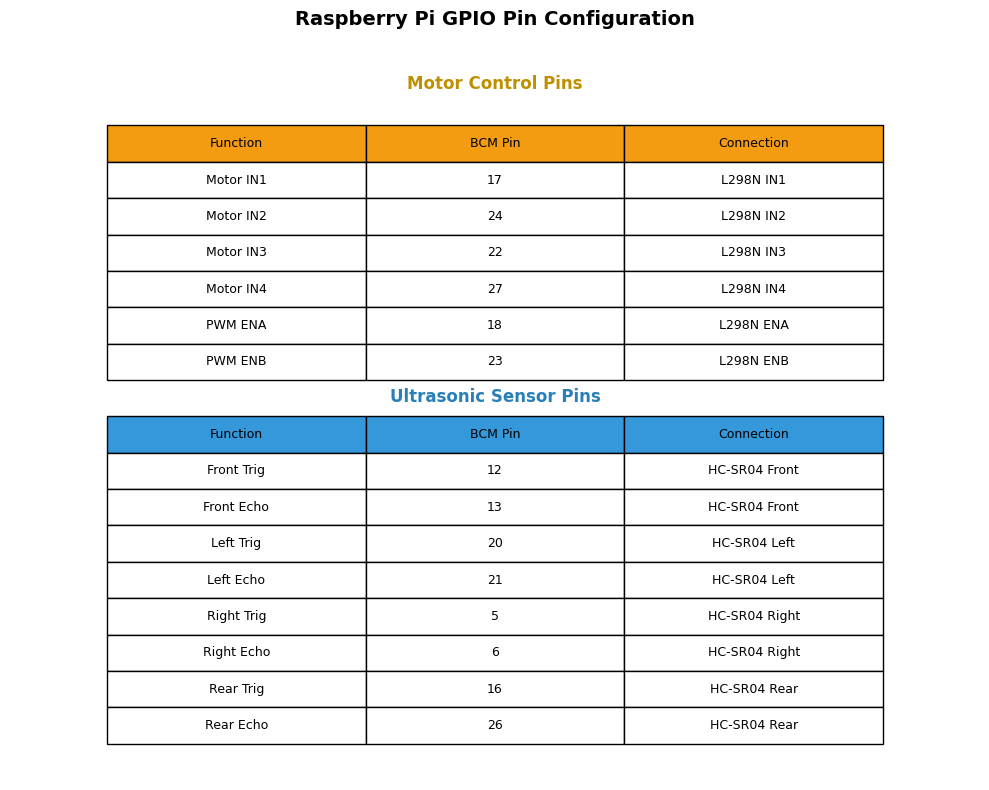

In [810]:

# 15
#!/usr/bin/env python3
"""GPIO Pin Configuration Table"""

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(10, 8))
ax.axis('off')
ax.set_title('Raspberry Pi GPIO Pin Configuration', fontsize=14, fontweight='bold', pad=20)

# Motor pins data
motor_data = [
    ['Function', 'BCM Pin', 'Connection'],
    ['Motor IN1', '17', 'L298N IN1'],
    ['Motor IN2', '24', 'L298N IN2'],
    ['Motor IN3', '22', 'L298N IN3'],
    ['Motor IN4', '27', 'L298N IN4'],
    ['PWM ENA', '18', 'L298N ENA'],
    ['PWM ENB', '23', 'L298N ENB'],
]

# Ultrasonic pins data
ultra_data = [
    ['Function', 'BCM Pin', 'Connection'],
    ['Front Trig', '12', 'HC-SR04 Front'],
    ['Front Echo', '13', 'HC-SR04 Front'],
    ['Left Trig', '20', 'HC-SR04 Left'],
    ['Left Echo', '21', 'HC-SR04 Left'],
    ['Right Trig', '5', 'HC-SR04 Right'],
    ['Right Echo', '6', 'HC-SR04 Right'],
    ['Rear Trig', '16', 'HC-SR04 Rear'],
    ['Rear Echo', '26', 'HC-SR04 Rear'],
]

# Create motor table
motor_table = ax.table(cellText=motor_data[1:], colLabels=motor_data[0],
                       loc='upper center', cellLoc='center',
                       colColours=['#F39C12']*3,
                       bbox=[0.1, 0.55, 0.8, 0.35])
motor_table.auto_set_font_size(False)
motor_table.set_fontsize(9)
motor_table.scale(1, 1.5)

# Create ultrasonic table
ultra_table = ax.table(cellText=ultra_data[1:], colLabels=ultra_data[0],
                       loc='center', cellLoc='center',
                       colColours=['#3498DB']*3,
                       bbox=[0.1, 0.05, 0.8, 0.45])
ultra_table.auto_set_font_size(False)
ultra_table.set_fontsize(9)
ultra_table.scale(1, 1.5)

ax.text(0.5, 0.95, 'Motor Control Pins', fontsize=12, fontweight='bold', 
        ha='center', transform=ax.transAxes, color='#bf8f00')
ax.text(0.5, 0.52, 'Ultrasonic Sensor Pins', fontsize=12, fontweight='bold',
        ha='center', transform=ax.transAxes, color='#2980b9')

plt.tight_layout()
plt.show()

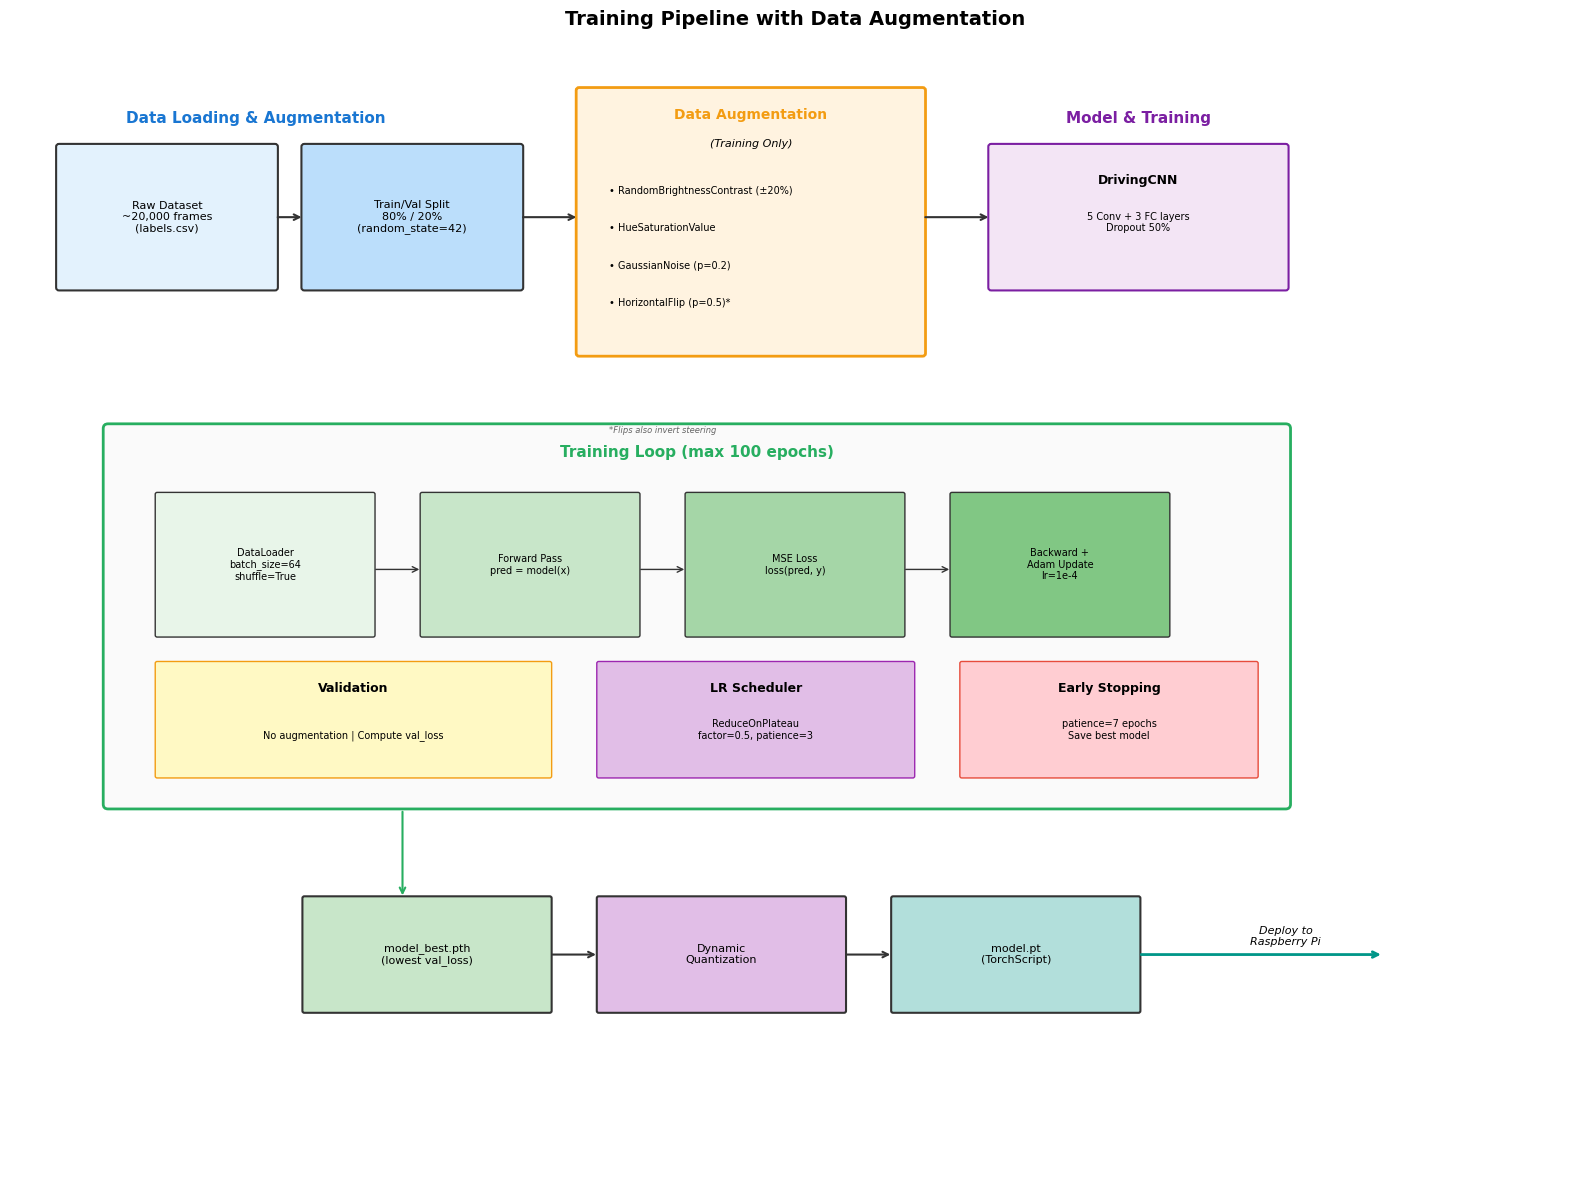

In [812]:
# 16

#!/usr/bin/env python3
"""Training Pipeline Diagram with Data Augmentation"""

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Rectangle

fig, ax = plt.subplots(figsize=(16, 12))
ax.set_xlim(0, 16)
ax.set_ylim(0, 12)
ax.axis('off')
ax.set_title('Training Pipeline with Data Augmentation', fontsize=14, fontweight='bold', pad=20)

# === DATA LOADING SECTION ===
ax.text(2.5, 11.25, 'Data Loading & Augmentation', fontsize=11, fontweight='bold', 
        ha='center', color='#1976D2')

data_steps = [
    (0.5, 9.5, 'Raw Dataset\n~20,000 frames\n(labels.csv)', '#e3f2fd'),
    (3, 9.5, 'Train/Val Split\n80% / 20%\n(random_state=42)', '#bbdefb'),
]

for x, y, text, color in data_steps:
    box = FancyBboxPatch((x, y), 2.2, 1.5, boxstyle="round,pad=0.03",
                         facecolor=color, edgecolor='#333', linewidth=1.5)
    ax.add_patch(box)
    ax.text(x + 1.1, y + 0.75, text, fontsize=8, ha='center', va='center')

ax.annotate('', xy=(3, 10.25), xytext=(2.7, 10.25),
           arrowprops=dict(arrowstyle='->', color='#333', lw=1.5))

# === AUGMENTATION SECTION ===
aug_box = FancyBboxPatch((5.8, 8.8), 3.5, 2.8, boxstyle="round,pad=0.03",
                          facecolor='#fff3e0', edgecolor='#F39C12', linewidth=2)
ax.add_patch(aug_box)
ax.text(7.55, 11.3, 'Data Augmentation', fontsize=10, fontweight='bold', ha='center', color='#F39C12')
ax.text(7.55, 11, '(Training Only)', fontsize=8, ha='center', style='italic')

augmentations = [
    'RandomBrightnessContrast (±20%)',
    'HueSaturationValue',
    'GaussianNoise (p=0.2)',
    'HorizontalFlip (p=0.5)*',
]
for i, aug in enumerate(augmentations):
    ax.text(6.1, 10.5 - i*0.4, f'• {aug}', fontsize=7)

ax.text(6.1, 7.95, '*Flips also invert steering', fontsize=6, style='italic', color='#666')

ax.annotate('', xy=(5.8, 10.25), xytext=(5.2, 10.25),
           arrowprops=dict(arrowstyle='->', color='#333', lw=1.5))

# === MODEL SECTION ===
ax.text(11.5, 11.25, 'Model & Training', fontsize=11, fontweight='bold', 
        ha='center', color='#7B1FA2')

model_box = FancyBboxPatch((10, 9.5), 3, 1.5, boxstyle="round,pad=0.03",
                            facecolor='#f3e5f5', edgecolor='#7B1FA2', linewidth=1.5)
ax.add_patch(model_box)
ax.text(11.5, 10.6, 'DrivingCNN', fontsize=9, fontweight='bold', ha='center')
ax.text(11.5, 10.1, '5 Conv + 3 FC layers\nDropout 50%', fontsize=7, ha='center')

ax.annotate('', xy=(10, 10.25), xytext=(9.3, 10.25),
           arrowprops=dict(arrowstyle='->', color='#333', lw=1.5))

# === TRAINING LOOP ===
loop_box = FancyBboxPatch((1, 4), 12, 4, boxstyle="round,pad=0.05",
                           facecolor='#fafafa', edgecolor='#27AE60', linewidth=2)
ax.add_patch(loop_box)
ax.text(7, 7.7, 'Training Loop (max 100 epochs)', fontsize=11, fontweight='bold', 
        ha='center', color='#27AE60')

# Training components
train_components = [
    (1.5, 5.8, 'DataLoader\nbatch_size=64\nshuffle=True', '#e8f5e9'),
    (4.2, 5.8, 'Forward Pass\npred = model(x)', '#c8e6c9'),
    (6.9, 5.8, 'MSE Loss\nloss(pred, y)', '#a5d6a7'),
    (9.6, 5.8, 'Backward +\nAdam Update\nlr=1e-4', '#81c784'),
]

for x, y, text, color in train_components:
    box = FancyBboxPatch((x, y), 2.2, 1.5, boxstyle="round,pad=0.02",
                         facecolor=color, edgecolor='#333', linewidth=1)
    ax.add_patch(box)
    ax.text(x + 1.1, y + 0.75, text, fontsize=7, ha='center', va='center')

for i in range(3):
    ax.annotate('', xy=(4.2 + i*2.7, 6.5), xytext=(3.7 + i*2.7, 6.5),
               arrowprops=dict(arrowstyle='->', color='#333', lw=1))

# Validation & Callbacks
val_box = FancyBboxPatch((1.5, 4.3), 4, 1.2, boxstyle="round,pad=0.02",
                          facecolor='#fff9c4', edgecolor='#F39C12', linewidth=1)
ax.add_patch(val_box)
ax.text(3.5, 5.2, 'Validation', fontsize=9, fontweight='bold', ha='center')
ax.text(3.5, 4.7, 'No augmentation | Compute val_loss', fontsize=7, ha='center')

lr_box = FancyBboxPatch((6, 4.3), 3.2, 1.2, boxstyle="round,pad=0.02",
                         facecolor='#e1bee7', edgecolor='#9C27B0', linewidth=1)
ax.add_patch(lr_box)
ax.text(7.6, 5.2, 'LR Scheduler', fontsize=9, fontweight='bold', ha='center')
ax.text(7.6, 4.7, 'ReduceOnPlateau\nfactor=0.5, patience=3', fontsize=7, ha='center')

early_box = FancyBboxPatch((9.7, 4.3), 3, 1.2, boxstyle="round,pad=0.02",
                            facecolor='#ffcdd2', edgecolor='#E74C3C', linewidth=1)
ax.add_patch(early_box)
ax.text(11.2, 5.2, 'Early Stopping', fontsize=9, fontweight='bold', ha='center')
ax.text(11.2, 4.7, 'patience=7 epochs\nSave best model', fontsize=7, ha='center')

# === OUTPUT ===
output_steps = [
    (3, 1.8, 'model_best.pth\n(lowest val_loss)', '#c8e6c9'),
    (6, 1.8, 'Dynamic\nQuantization', '#e1bee7'),
    (9, 1.8, 'model.pt\n(TorchScript)', '#b2dfdb'),
]

for x, y, text, color in output_steps:
    box = FancyBboxPatch((x, y), 2.5, 1.2, boxstyle="round,pad=0.02",
                         facecolor=color, edgecolor='#333', linewidth=1.5)
    ax.add_patch(box)
    ax.text(x + 1.25, y + 0.6, text, fontsize=8, ha='center', va='center')

ax.annotate('', xy=(4, 3), xytext=(4, 3.95),
           arrowprops=dict(arrowstyle='->', color='#27AE60', lw=1.5))
ax.annotate('', xy=(6, 2.4), xytext=(5.5, 2.4),
           arrowprops=dict(arrowstyle='->', color='#333', lw=1.5))
ax.annotate('', xy=(9, 2.4), xytext=(8.5, 2.4),
           arrowprops=dict(arrowstyle='->', color='#333', lw=1.5))

ax.text(13, 2.5, 'Deploy to\nRaspberry Pi', fontsize=8, ha='center', style='italic')
ax.annotate('', xy=(14, 2.4), xytext=(11.5, 2.4),
           arrowprops=dict(arrowstyle='->', color='#009688', lw=2))

plt.tight_layout()
plt.show()